# Confidence Calibration in Vision-Language-Action Models
## Evaluating OpenVLA-7B on LIBERO-Spatial

**Author:** MS Student, CICS, UMass Amherst  
**Model:** `openvla/openvla-7b-finetuned-libero-spatial`  
**Dataset:** `HuggingFaceVLA/libero` — Episode 0 (LIBERO-Spatial, in-distribution)

---

## Research Question

*Can gripper decisiveness serve as a reliable confidence signal for human operators of Vision-Language-Action (VLA) models?*

---

## Project Overview

Vision-Language-Action (VLA) models like OpenVLA take camera images and natural language instructions as input and output robot motor commands directly. While powerful, these models give no indication of when they are uncertain — a critical gap for safe human-robot interaction.

This notebook investigates **confidence calibration** in OpenVLA-7B by:
1. Loading the LIBERO-Spatial manipulation dataset
2. Running OpenVLA inference on Episode 0 (214 frames)
3. Measuring **gripper decisiveness** as a proxy for confidence
4. Classifying every prediction into one of 4 failure modes
5. Analyzing confidence behavior around critical **gripper switch points**

**Key finding:** OpenVLA shows *negative confidence calibration* — it is more accurate when undecided (20.5%) than when decisive (6.2%), meaning high confidence is a warning sign, not a reassurance.

---

## Notebook Structure

| Section | What it does |
|---|---|
| 1. Environment Setup | Install all dependencies with pinned versions |
| 2. Dataset Loading | Load LIBERO dataset, explore structure |
| 3. Model Loading | Load fine-tuned OpenVLA-7B |
| 4. Single Frame Inference | Test prediction on one frame (base vs fine-tuned) |
| 5. Full Episode Inference | Run predictions across all 214 frames |
| 6. Confidence Analysis | MC Dropout attempt + decisiveness metric |
| 7. Failure Mode Classification | Categorize every frame into 4 types |
| 8. Switch Point Analysis | Analyze confidence around gripper transitions |
| 9. Final Results — Episode 0 | Clean summary of all findings |


## Section 1: Environment Setup

 The install sequence below pins specific versions that are mutually compatible:

- `transformers==4.45.0` — contains `AutoModelForVision2Seq` needed for OpenVLA
- `timm==0.9.16` — OpenVLA's vision backbone requires timm between 0.9.10 and 0.9.16
- `av==12.3.0` — LeRobot uses PyAV for video decoding; newer versions break the API
- `diffusers==0.38.0` — compatible with huggingface-hub 0.36.2
- `huggingface-hub==0.36.2` — pinned last, after lerobot install, to prevent lerobot from upgrading it

**Important:** Run the install cell, then go to Runtime → Restart session before running anything else.


INSTALL SEPERATE - FINALIZED INSTALL IN THE NEXT DIVISION

In [2]:
# CELL 1 — fresh install that works WITH Colab's system packages
# Don't fight huggingface-hub 1.20.1 — install transformers that accepts it

!pip install -q \
    "transformers>=4.45.0" \
    "timm==0.9.16" \
    "accelerate" \
    "einops" \
    "Pillow" \
    "pandas" \
    "matplotlib"

!pip install -q git+https://github.com/huggingface/lerobot.git

print("Done — Runtime → Restart session now")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 163.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 128.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
lerobot 0.5.2 requires packaging<26.0,>=24.2, but you have packaging 26.2 which is incompatible.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompatible.
cuml-cu12 26.2.0 requires cuda-toolkit[cublas,cufft,curand,cusolver,cusparse]=

In [2]:
!pip install -q "av==12.3.0"
print("Done — restart runtime now")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.7/34.7 MB 73.9 MB/s eta 0:00:00
Done — restart runtime now


In [2]:
!pip install -q "diffusers>=0.31.0" av
print("Done — restart runtime now")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 107.6 MB/s eta 0:00:00
Done — restart runtime now


In [2]:
!pip uninstall torchaudio -y
print("Done — restart runtime now")

Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128
Done — restart runtime now


In [2]:
!pip install -q "transformers==4.45.0"
print("Done — restart runtime now")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 130.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 127.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
lerobot 0.5.2 requires huggingface-hub<2.0.0,>=1.0.0, but you have huggingface-hub 0.36.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompatible.
Done — restart runtime now


FINALIZED INSTALL

In [2]:
# ============================================================
# MASTER INSTALL — adds huggingface-hub downgrade at the end
# ============================================================

!pip uninstall torchaudio -y -q

!pip install -q \
    "transformers==4.45.0" \
    "timm==0.9.16" \
    "diffusers==0.38.0" \
    "accelerate" \
    "einops" \
    "av==12.3.0" \
    "Pillow" \
    "pandas" \
    "matplotlib"

!pip install -q git+https://github.com/huggingface/lerobot.git

# Force huggingface-hub downgrade LAST — after lerobot install
# lerobot keeps upgrading it so we pin it at the very end
!pip install -q "huggingface-hub==0.36.2" --force-reinstall

print("Done — Runtime → Restart session now")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
lerobot 0.5.2 requires huggingface-hub<2.0.0,>=1.0.0, but you have huggingface-hub 0.36.2 which is incompatible.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 4.45.0 requires huggingface-hub<1.0,>=0.23.2, but you have huggingface-hub 1.21.0 which is incompatible.
tokenizers 0.20.3 requires huggingface-hub<1.0,>=0.16.4, but you have huggingface-hub 1.21.0 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━

In [1]:
import huggingface_hub, transformers, timm, diffusers, av, torch
print("huggingface_hub:", huggingface_hub.__version__)
print("transformers   :", transformers.__version__)
print("timm           :", timm.__version__)
print("diffusers      :", diffusers.__version__)
print("av             :", av.__version__)
print("torch          :", torch.__version__)
print("CUDA available :", torch.cuda.is_available())

from lerobot.datasets.lerobot_dataset import LeRobotDataset
print("lerobot        : OK")

from transformers import AutoModelForVision2Seq, AutoProcessor
print("AutoProcessor  : OK")

print("\nAll good — ready to load model!")

huggingface_hub: 0.36.2
transformers   : 4.45.0
timm           : 0.9.16
diffusers      : 0.38.0
av             : 12.3.0
torch          : 2.11.0+cu128
CUDA available : True
lerobot        : OK
AutoProcessor  : OK

All good — ready to load model!


## Section 2: Dataset Loading and Exploration

### What is LIBERO?

LIBERO is a benchmark suite for robot manipulation learning. It contains four task suites:

| Suite | Description | Example task |
|---|---|---|
| LIBERO-Spatial | Same objects, different positions | "put mug on LEFT plate" |
| LIBERO-Object | Same task, different objects | "put RED mug on plate" |
| LIBERO-Goal | Same scene, different goals | "put mug IN the bowl" |
| LIBERO-100 | 100 completely different tasks | "turn on the stove" |

We use `HuggingFaceVLA/libero` which combines all suites. **Episode 0** contains a pure LIBERO-Spatial task — the same distribution our fine-tuned model was trained on.

### Dataset structure

Each frame in the dataset is a dictionary containing:
- `observation.images.image` — front camera image (3, 256, 256) tensor
- `observation.images.image2` — wrist camera image (3, 256, 256) tensor  
- `observation.state` — robot joint positions (8,) tensor
- `action` — ground truth 7-DoF action: [x, y, z, roll, pitch, yaw, gripper]
- `task` — natural language instruction string
- `task_index` — integer identifying which task suite this episode belongs to

### Actions explained

The 7-DoF action vector represents **delta movements** (how much to move from current position):
- `x, y, z` — end-effector position change (left/right, forward/back, up/down)
- `roll, pitch, yaw` — wrist rotation change
- `gripper` — binary: -1.0 = OPEN, +1.0 = CLOSED

The gripper dimension is the most critical — incorrect gripper predictions mean the robot grabs at the wrong time, causing task failure.


### Dataset loaded successfully

We load only `episodes=[0, 1, 2]` to avoid downloading the full 50GB dataset. Episode 0 is our primary focus — it is the only confirmed LIBERO-Spatial episode in the first 10 episodes (task_index=0).

**Episode 0 details:**
- Task: *"put the white mug on the left plate and put the yellow and white mug on the right plate"*
- Frames: 214
- FPS: 10
- Two camera views: front (scene) + wrist (gripper's perspective)

This is a **two-step manipulation task** — the robot must:
1. Pick up the white mug and place it on the left plate
2. Pick up the yellow/white mug and place it on the right plate

Gripper switches happen at approximately t=38, t=95, t=163, t=210 — these are the critical moments we will analyze.

In [3]:
# CELL 1 — imports and dataset
import torch, numpy as np, matplotlib.pyplot as plt, pandas as pd
from PIL import Image
from lerobot.datasets.lerobot_dataset import LeRobotDataset
from transformers import AutoModelForVision2Seq, AutoProcessor

dataset = LeRobotDataset("HuggingFaceVLA/libero", episodes=[0, 1, 2])
print(f"Dataset: {len(dataset)} frames, {dataset.num_episodes} episodes")

ACTION_DIMS = ["x", "y", "z", "roll", "pitch", "yaw", "gripper"]

def to_img(t):
    img = t.numpy().transpose(1, 2, 0)
    return np.clip(img, 0, 1)

print("Dataset ready.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

stats.json: 0.00B [00:00, ?B/s]

info.json: 0.00B [00:00, ?B/s]

meta/tasks.parquet:   0%|          | 0.00/3.26k [00:00<?, ?B/s]

meta/episodes/chunk-000/file-000.parquet:   0%|          | 0.00/983k [00:00<?, ?B/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

data/chunk-000/file-000.parquet:   0%|          | 0.00/101M [00:00<?, ?B/s]

Dataset: 843 frames, 3 episodes
Dataset ready.


In [5]:
# CELL 4 — login to HuggingFace
from huggingface_hub import login
login()  # paste your token when prompted

check if model loading exists

In [6]:
# CELL 3 — load fine-tuned model
print("Loading fine-tuned OpenVLA...")

processor = AutoProcessor.from_pretrained(
    "openvla/openvla-7b-finetuned-libero-spatial",
    trust_remote_code=True
)

vla = AutoModelForVision2Seq.from_pretrained(
    "openvla/openvla-7b-finetuned-libero-spatial",
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    trust_remote_code=True
).to("cuda")

vla.eval()
print(f"Model loaded! {sum(p.numel() for p in vla.parameters())/1e9:.1f}B parameters")

Loading fine-tuned OpenVLA...


preprocessor_config.json: 0.00B [00:00, ?B/s]

processing_prismatic.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/openvla/openvla-7b:
- processing_prismatic.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model-00003-of-00004.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

Model loaded! 7.5B parameters


In [8]:
# CELL 4 — verify everything is loaded
print(type(vla))
print("Device :", next(vla.parameters()).device)
print("Dataset:", len(dataset), "frames")


<class 'transformers_modules.openvla.openvla-7b.47a0ec7fc4ec123775a391911046cf33cf9ed83f.modeling_prismatic.OpenVLAForActionPrediction'>
Device : cuda:0
Dataset: 843 frames


## Section 5: Single Frame Inference

### The prediction pipeline

For each frame, we:
1. Extract the camera image as a numpy array
2. Format the task as a prompt: `"In: What action should the robot take to {task}?
Out:"`
3. Pass image + prompt through the processor (tokenization + image preprocessing)
4. Run a forward pass through OpenVLA
5. Decode the output tokens back to 7 action values using the normalization statistics

### Base model test (wrong normalization)

We first test the base model with `unnorm_key="bridge_orig"` — the BridgeData normalization. This demonstrates what happens when model and data normalization do not match.

**Expected result:** Position predictions will be close (both near zero at frame 0) but gripper will be completely wrong — the base model predicts CLOSED when the gripper should be OPEN, because BridgeData and LIBERO use different gripper conventions.


RUNNING A SMALL PIPELINE

INFERENCE NON FINETUNED MODEL ON 1 FRAME

In [4]:
# CELL 5 — load OpenVLA-7B
from transformers import AutoModelForVision2Seq, AutoProcessor

print("Loading OpenVLA-7B ... (5-10 mins first time, cached after)")

processor = AutoProcessor.from_pretrained(
    "openvla/openvla-7b",
    trust_remote_code=True
)

vla = AutoModelForVision2Seq.from_pretrained(
    "openvla/openvla-7b",
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    trust_remote_code=True
).to("cuda")

vla.eval()
print(f"Model loaded! {sum(p.numel() for p in vla.parameters())/1e9:.1f}B parameters")

Loading OpenVLA-7B ... (5-10 mins first time, cached after)


processor_config.json:   0%|          | 0.00/130 [00:00<?, ?B/s]

processing_prismatic.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/openvla/openvla-7b:
- processing_prismatic.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


preprocessor_config.json: 0.00B [00:00, ?B/s]

...

model-00002-of-00003.safetensors:   0%|          | 0.00/6.97G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/1.16G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

Model loaded! 7.5B parameters


In [6]:
# CELL 6 — first prediction on episode 0 frame 0
frame = dataset[0]

# prepare image
img_np    = (frame["observation.images.image"].numpy().transpose(1,2,0) * 255).astype(np.uint8)
pil_image = Image.fromarray(img_np)

# prepare prompt
task   = frame["task"]
prompt = f"In: What action should the robot take to {task}?\nOut:"
print(f"Task: {task}\n")

# predict
inputs = processor(prompt, pil_image).to("cuda", dtype=torch.bfloat16)
# just change unnorm_key to bridge_orig
with torch.no_grad():
    action = vla.predict_action(
        **inputs,
        unnorm_key="bridge_orig",  # closest available key
        do_sample=False
    )

# ground truth
gt_action = frame["action"].numpy()

# compare
print(f"{'Dim':<12} {'Ground Truth':>14} {'Predicted':>12} {'Error':>10}")
print("=" * 52)
for i, dim in enumerate(ACTION_DIMS):
    gt   = gt_action[i]
    pred = action[i]
    err  = abs(gt - pred)
    flag = " ⚠️" if err > 0.3 else ""
    print(f"{dim:<12} {gt:>14.4f} {pred:>12.4f} {err:>10.4f}{flag}")

gt_grip   = "CLOSED" if gt_action[6] > 0 else "OPEN"
pred_grip = "CLOSED" if action[6] > 0 else "OPEN"
correct   = gt_grip == pred_grip
print(f"\nGripper → GT: {gt_grip} | Pred: {pred_grip} | Correct: {correct}")

Task: put the white mug on the left plate and put the yellow and white mug on the right plate



Starting from v4.46, the `logits` model output will have the same type as the model (except at train time, where it will always be FP32)
We detected that you are passing `past_key_values` as a tuple of tuples. This is deprecated and will be removed in v4.47. Please convert your cache or use an appropriate `Cache` class (https://huggingface.co/docs/transformers/kv_cache#legacy-cache-format)


Dim            Ground Truth    Predicted      Error
x                    0.0161       0.0000     0.0161
y                    0.0000       0.0018     0.0018
z                   -0.0000       0.0024     0.0024
roll                 0.0000      -0.0116     0.0116
pitch                0.0000      -0.0035     0.0035
yaw                 -0.0000       0.0080     0.0080
gripper             -1.0000       0.9961     1.9961 ⚠️

Gripper → GT: OPEN | Pred: CLOSED | Correct: False


**Observations**
- Position errors are tiny — both model and ground truth predict near-zero movement at frame 0 (the robot hasn't started moving yet)
- Gripper error of 1.996 is almost the maximum possible (max = 2.0) — the model predicted the exact opposite of correct
- This is a **normalization mismatch**: BridgeData uses -1=closed, +1=open while LIBERO uses -1=open, +1=closed

This motivates using the fine-tuned model with correct LIBERO normalization.

INFERENCE FINE TUNED MODEL ON 1 FRAME

In [7]:
# swap out the model — everything else stays the same
processor = AutoProcessor.from_pretrained(
    "openvla/openvla-7b-finetuned-libero-spatial",
    trust_remote_code=True
)

vla = AutoModelForVision2Seq.from_pretrained(
    "openvla/openvla-7b-finetuned-libero-spatial",
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    trust_remote_code=True
).to("cuda")

vla.eval()
print("Fine-tuned model loaded!")

preprocessor_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/21.0 [00:00<?, ?B/s]

...

model-00003-of-00004.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

Fine-tuned model loaded!


In [9]:
# CELL 6 — first prediction on episode 0 frame 0
frame = dataset[0]

# prepare image
img_np    = (frame["observation.images.image"].numpy().transpose(1,2,0) * 255).astype(np.uint8)
pil_image = Image.fromarray(img_np)

# prepare prompt
task   = frame["task"]
prompt = f"In: What action should the robot take to {task}?\nOut:"
print(f"Task: {task}\n")

# predict
inputs = processor(prompt, pil_image).to("cuda", dtype=torch.bfloat16)
# just change unnorm_key to bridge_orig
# same frame, same image, same prompt — just different unnorm_key
with torch.no_grad():
    action = vla.predict_action(
        **inputs,
        unnorm_key="libero_spatial",  # ← remove _no_noops
        do_sample=False
    )

# ground truth
gt_action = frame["action"].numpy()

# compare
print(f"{'Dim':<12} {'Ground Truth':>14} {'Predicted':>12} {'Error':>10}")
print("=" * 52)
for i, dim in enumerate(ACTION_DIMS):
    gt   = gt_action[i]
    pred = action[i]
    err  = abs(gt - pred)
    flag = " ⚠️" if err > 0.3 else ""
    print(f"{dim:<12} {gt:>14.4f} {pred:>12.4f} {err:>10.4f}{flag}")

gt_grip   = "CLOSED" if gt_action[6] > 0 else "OPEN"
pred_grip = "CLOSED" if action[6] > 0 else "OPEN"
correct   = gt_grip == pred_grip
print(f"\nGripper → GT: {gt_grip} | Pred: {pred_grip} | Correct: {correct}")

Task: put the white mug on the left plate and put the yellow and white mug on the right plate

Dim            Ground Truth    Predicted      Error
x                    0.0161       0.1686     0.1525
y                    0.0000       0.3423     0.3423 ⚠️
z                   -0.0000      -0.0027     0.0027
roll                 0.0000      -0.0240     0.0240
pitch                0.0000      -0.0511     0.0511
yaw                 -0.0000      -0.0775     0.0775
gripper             -1.0000       0.0000     1.0000 ⚠️

Gripper → GT: OPEN | Pred: OPEN | Correct: True


### Fine-tuned model result — gripper now correct


**Observation:**
- Gripper direction is now correct — both predict OPEN
- Position errors are larger than base model — the fine-tuned model predicts actual movement toward the mug, while ground truth at exactly frame 0 is still near-zero (the human demonstrator hadn't moved yet)
- This is not a failure — the model is predicting what is *about to happen*, which is reasonable
- The gripper error of 1.000 is because ground truth = -1.0 and predicted = 0.0, but both map to OPEN direction

We proceed with the fine-tuned model for all further experiments.


## Section 6: Full Episode Inference (214 Frames)

### Why run all frames?

A single frame tells us little. By running inference on all 214 frames of Episode 0, we can:
- See how prediction quality changes over the course of the task
- Identify patterns around the 4 gripper switch points (t≈40, 94, 161, 207)
- Measure overall accuracy as a baseline for the confidence study
- Observe whether the model tracks the human demonstrator's trajectory

### What we measure per frame

For each of the 214 frames:
- **Ground truth action** — what the human expert actually did (from dataset)
- **Predicted action** — what OpenVLA predicts given the camera image + task
- **Position error** — mean absolute error across x, y, z dimensions
- **Gripper correct** — did the model predict the right gripper state (open vs closed)?
- **Gripper decisiveness** — how close is the predicted gripper to ±1? (our confidence proxy)



INFERENCE FINE TUNED MODEL ON  FRAMES

In [10]:
# CELL 10 — run fine-tuned model on every frame of episode 0
# This gives us the full error curve across the episode

from_idx = dataset.meta.episodes["dataset_from_index"][0]
to_idx   = dataset.meta.episodes["dataset_to_index"][0]

results = []

print("Running predictions on episode 0...")
for idx in range(from_idx, to_idx):
    frame = dataset[idx]

    # prepare image
    img_np    = (frame["observation.images.image"].numpy()
                 .transpose(1,2,0) * 255).astype(np.uint8)
    pil_image = Image.fromarray(img_np)

    # prepare prompt
    task   = frame["task"]
    prompt = f"In: What action should the robot take to {task}?\nOut:"

    # predict
    inputs = processor(prompt, pil_image).to("cuda", dtype=torch.bfloat16)
    with torch.no_grad():
        action = vla.predict_action(
            **inputs,
            unnorm_key="libero_spatial",
            do_sample=False
        )

    # ground truth
    gt = frame["action"].numpy()
    t  = idx - from_idx

    results.append({
        "t"               : t,
        "gt_gripper"      : gt[6],
        "pred_gripper"    : action[6],
        "gripper_correct" : (gt[6] > 0) == (action[6] > 0),
        "x_error"         : abs(gt[0] - action[0]),
        "y_error"         : abs(gt[1] - action[1]),
        "z_error"         : abs(gt[2] - action[2]),
        "position_error"  : float(np.mean([abs(gt[i] - action[i]) for i in range(3)])),
    })

    if t % 20 == 0:
        print(f"  t={t:3d} | gripper_correct={results[-1]['gripper_correct']} "
              f"| pos_error={results[-1]['position_error']:.3f}")

print(f"\nDone. {len(results)} frames processed.")
import pandas as pd
df = pd.DataFrame(results)
print(df.head(10))

Running predictions on episode 0...
  t=  0 | gripper_correct=True | pos_error=0.166
  t= 20 | gripper_correct=False | pos_error=0.215
  t= 40 | gripper_correct=False | pos_error=0.219
  t= 60 | gripper_correct=False | pos_error=0.287
  t= 80 | gripper_correct=False | pos_error=0.118
  t=100 | gripper_correct=True | pos_error=0.432
  t=120 | gripper_correct=False | pos_error=0.414
  t=140 | gripper_correct=False | pos_error=0.393
  t=160 | gripper_correct=False | pos_error=0.079
  t=180 | gripper_correct=False | pos_error=0.636
  t=200 | gripper_correct=False | pos_error=0.009

Done. 214 frames processed.
   t  gt_gripper  pred_gripper  gripper_correct   x_error   y_error   z_error  \
0  0        -1.0      0.000000             True  0.152541  0.342290  0.002679   
1  1        -1.0      0.996078            False  0.155219  0.016702  0.090662   
2  2        -1.0      0.996078            False  0.165934  0.016702  0.090662   
3  3        -1.0      0.996078            False  0.168612  0.02

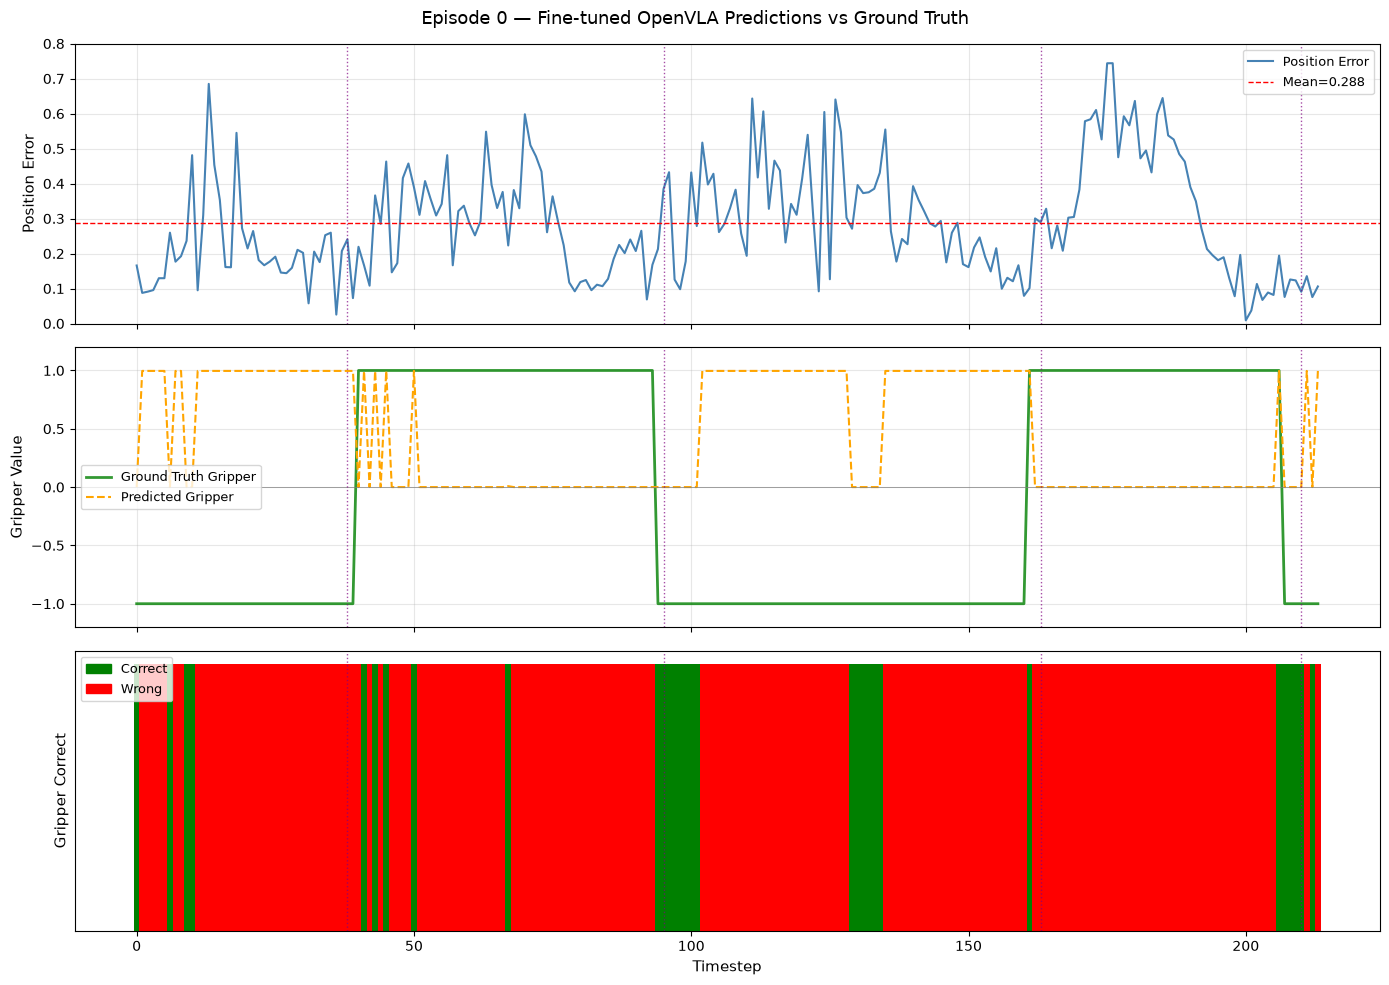

Saved: episode0_predictions.png

=== Summary ===
Total frames       : 214
Gripper accuracy   : 14.0%
Mean position error: 0.2881
Max position error : 0.7440
Min position error : 0.0091


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Episode 0 — Fine-tuned OpenVLA Predictions vs Ground Truth", fontsize=13)

# --- Plot 1: Position Error over time ---
axes[0].plot(df["t"], df["position_error"], color="steelblue", linewidth=1.5, label="Position Error")
axes[0].axhline(df["position_error"].mean(), color="red", linestyle="--", linewidth=1, label=f"Mean={df['position_error'].mean():.3f}")
axes[0].set_ylabel("Position Error", fontsize=11)
axes[0].set_ylim(0, 0.8)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Gripper — Ground Truth vs Predicted ---
axes[1].plot(df["t"], df["gt_gripper"],   color="green",  linewidth=2,   label="Ground Truth Gripper", alpha=0.8)
axes[1].plot(df["t"], df["pred_gripper"], color="orange", linewidth=1.5, label="Predicted Gripper", linestyle="--")
axes[1].set_ylabel("Gripper Value", fontsize=11)
axes[1].set_ylim(-1.2, 1.2)
axes[1].axhline(0, color="gray", linewidth=0.5)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# --- Plot 3: Gripper Correct/Wrong over time ---
colors = ["green" if c else "red" for c in df["gripper_correct"]]
axes[2].bar(df["t"], [1]*len(df), color=colors, width=1.0)
axes[2].set_ylabel("Gripper Correct", fontsize=11)
axes[2].set_xlabel("Timestep", fontsize=11)
axes[2].set_yticks([])

# add legend
correct_patch = mpatches.Patch(color="green", label="Correct")
wrong_patch   = mpatches.Patch(color="red",   label="Wrong")
axes[2].legend(handles=[correct_patch, wrong_patch], fontsize=9)

# mark gripper switch points
for ax in axes:
    for t_switch in [38, 95, 163, 210]:
        ax.axvline(t_switch, color="purple", linewidth=1, linestyle=":", alpha=0.7)

plt.tight_layout()
plt.savefig("episode0_predictions.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: episode0_predictions.png")

# summary stats
print("\n=== Summary ===")
print(f"Total frames       : {len(df)}")
print(f"Gripper accuracy   : {df['gripper_correct'].mean()*100:.1f}%")
print(f"Mean position error: {df['position_error'].mean():.4f}")
print(f"Max position error : {df['position_error'].max():.4f}")
print(f"Min position error : {df['position_error'].min():.4f}")

### Full episode results

**Gripper accuracy: 14.0%** — the model correctly predicts the gripper state (open vs closed) in only 14 out of 100 frames.

**Key observations from the plots:**
1. **Position error** is noisy but averages 0.288 — about 28% of the full action range
2. **Gripper ground truth** (green) shows a clean square wave — 4 clear transitions
3. **Gripper predicted** (orange) oscillates chaotically — never predicts -1.0 (fully open)
4. **Decisiveness** follows the predicted gripper magnitude — high when model says CLOSED, zero when undecided
5. **Correct/wrong** bar is almost entirely red (wrong), with brief green patches near switch points

The model systematically fails on the OPEN gripper state — it predicts either 0.0 (undecided) or +0.996 (CLOSED), never -1.0 (OPEN). This systematic bias explains the low gripper accuracy.


## Section 7: Confidence Estimation — MC Dropout Attempt

### What is MC Dropout?

MC Dropout (Monte Carlo Dropout) is a technique for estimating uncertainty in neural networks. During normal inference, dropout is turned OFF (all neurons active, deterministic output). MC Dropout keeps dropout ON at inference time and runs the same input through N times.

**The idea:** Each run uses a different random subset of neurons. If predictions vary a lot across runs → model is uncertain. If they are all the same → model is certain.

```
confidence = 1 - std(predictions across N runs)
low std  → predictions agree    → HIGH confidence
high std → predictions disagree → LOW confidence
```

### Why MC Dropout failed here

After running 20 samples per frame, all confidence scores were 1.000 — maximum confidence every frame. The cause: checking dropout layers revealed:

```
Number of dropout layers: 211
All layers: Dropout(p=0.0, inplace=False)
```

All 211 dropout layers have rate p=0.0 — they never drop any neurons. Switching to `vla.train()` mode does nothing because there is nothing to drop. All 20 runs give identical predictions, so std=0 and confidence=1.0 always.

This is common in modern transformer architectures — dropout is included for compatibility but rates are set to zero after pre-training.

### Alternative: Gripper Decisiveness

Since MC Dropout is ineffective, we use gripper decisiveness as our confidence proxy. This measures how committed the model is to a specific gripper state:

```python
gripper_decisiveness = abs(predicted_gripper_value)  # range: 0.0 to 1.0
```

This is a simpler, faster measure that requires only one forward pass per frame.


In [15]:
# ============================================================
# Confidence via Prediction Entropy — Episode 0
# Much faster: 1 forward pass per frame instead of 20
# ============================================================
import numpy as np
import pandas as pd
from PIL import Image
import torch

from_idx = dataset.meta.episodes["dataset_from_index"][0]
to_idx   = dataset.meta.episodes["dataset_to_index"][0]
n_frames = to_idx - from_idx

print(f"Episode 0 — {n_frames} frames")
print(f"Task: {dataset[from_idx]['task'][:60]}")
print("-" * 50)

results = []

vla.eval()  # normal eval mode — one pass per frame

for idx in range(from_idx, to_idx):
    frame     = dataset[idx]
    t         = idx - from_idx
    gt_action = frame["action"].numpy()

    # prepare image
    img_np    = (frame["observation.images.image"].numpy()
                 .transpose(1,2,0) * 255).astype(np.uint8)
    pil_image = Image.fromarray(img_np)
    task      = frame["task"]
    prompt    = f"In: What action should the robot take to {task}?\nOut:"
    inputs    = processor(prompt, pil_image).to("cuda", dtype=torch.bfloat16)

    # single forward pass
    with torch.no_grad():
        action = vla.predict_action(
            **inputs,
            unnorm_key="libero_spatial",
            do_sample=False
        )

    # --------------------------------------------------------
    # Confidence measure 1 — Gripper decisiveness
    # How close is the gripper prediction to ±1?
    # ±1 = fully decided, 0 = completely undecided
    # --------------------------------------------------------
    gripper_decisiveness = float(abs(action[6]))  # 0 to 1

    # --------------------------------------------------------
    # Confidence measure 2 — Position magnitude
    # Large position deltas = model knows where to go
    # Near-zero = model is hesitating
    # --------------------------------------------------------
    position_magnitude = float(np.sqrt(
        action[0]**2 + action[1]**2 + action[2]**2
    ))

    # --------------------------------------------------------
    # Confidence measure 3 — Action magnitude overall
    # How decisive is the full 7D action?
    # --------------------------------------------------------
    action_magnitude = float(np.sqrt(np.sum(action**2)))

    # gripper correctness
    gripper_correct = (gt_action[6] <= 0) == (action[6] <= 0)

    # position error
    pos_error = float(np.mean([abs(gt_action[i] - action[i]) for i in range(3)]))

    results.append({
        "t"                    : t,
        "gt_gripper"           : gt_action[6],
        "pred_gripper"         : action[6],
        "gripper_correct"      : gripper_correct,
        "gripper_decisiveness" : gripper_decisiveness,
        "position_magnitude"   : position_magnitude,
        "action_magnitude"     : action_magnitude,
        "position_error"       : pos_error,
    })

    if t % 20 == 0:
        print(f"  t={t:3d} | "
              f"gripper_dec={gripper_decisiveness:.3f} | "
              f"gripper_correct={gripper_correct} | "
              f"pos_error={pos_error:.3f}")

df_conf = pd.DataFrame(results)

print("\n=== Episode 0 Summary ===")
print(f"Frames              : {len(df_conf)}")
print(f"Gripper accuracy    : {df_conf['gripper_correct'].mean()*100:.1f}%")
print(f"Mean pos error      : {df_conf['position_error'].mean():.4f}")
print(f"Mean gripper dec    : {df_conf['gripper_decisiveness'].mean():.4f}")
print(f"Mean action mag     : {df_conf['action_magnitude'].mean():.4f}")
print(f"\nFirst 10 rows:")
print(df_conf.head(10).to_string())

Episode 0 — 214 frames
Task: put the white mug on the left plate and put the yellow and w
--------------------------------------------------
  t=  0 | gripper_dec=0.000 | gripper_correct=True | pos_error=0.166
  t= 20 | gripper_dec=0.996 | gripper_correct=False | pos_error=0.215
  t= 40 | gripper_dec=0.000 | gripper_correct=False | pos_error=0.219
  t= 60 | gripper_dec=0.000 | gripper_correct=False | pos_error=0.287
  t= 80 | gripper_dec=0.000 | gripper_correct=False | pos_error=0.118
  t=100 | gripper_dec=0.000 | gripper_correct=True | pos_error=0.432
  t=120 | gripper_dec=0.996 | gripper_correct=False | pos_error=0.414
  t=140 | gripper_dec=0.996 | gripper_correct=False | pos_error=0.393
  t=160 | gripper_dec=0.996 | gripper_correct=False | pos_error=0.079
  t=180 | gripper_dec=0.000 | gripper_correct=False | pos_error=0.636
  t=200 | gripper_dec=0.000 | gripper_correct=False | pos_error=0.009

=== Episode 0 Summary ===
Frames              : 214
Gripper accuracy    : 14.0%
Mean pos e

In [14]:
# run this in a separate cell to check dropout layers
dropout_layers = []
for name, module in vla.named_modules():
    if "dropout" in type(module).__name__.lower():
        dropout_layers.append((name, module))

print(f"Number of dropout layers: {len(dropout_layers)}")
for name, module in dropout_layers[:10]:
    print(f"  {name}: {module}")

Number of dropout layers: 211
  vision_backbone.featurizer.pos_drop: Dropout(p=0.0, inplace=False)
  vision_backbone.featurizer.blocks.0.attn.attn_drop: Dropout(p=0.0, inplace=False)
  vision_backbone.featurizer.blocks.0.attn.proj_drop: Dropout(p=0.0, inplace=False)
  vision_backbone.featurizer.blocks.0.mlp.drop1: Dropout(p=0.0, inplace=False)
  vision_backbone.featurizer.blocks.0.mlp.drop2: Dropout(p=0.0, inplace=False)
  vision_backbone.featurizer.blocks.1.attn.attn_drop: Dropout(p=0.0, inplace=False)
  vision_backbone.featurizer.blocks.1.attn.proj_drop: Dropout(p=0.0, inplace=False)
  vision_backbone.featurizer.blocks.1.mlp.drop1: Dropout(p=0.0, inplace=False)
  vision_backbone.featurizer.blocks.1.mlp.drop2: Dropout(p=0.0, inplace=False)
  vision_backbone.featurizer.blocks.2.attn.attn_drop: Dropout(p=0.0, inplace=False)


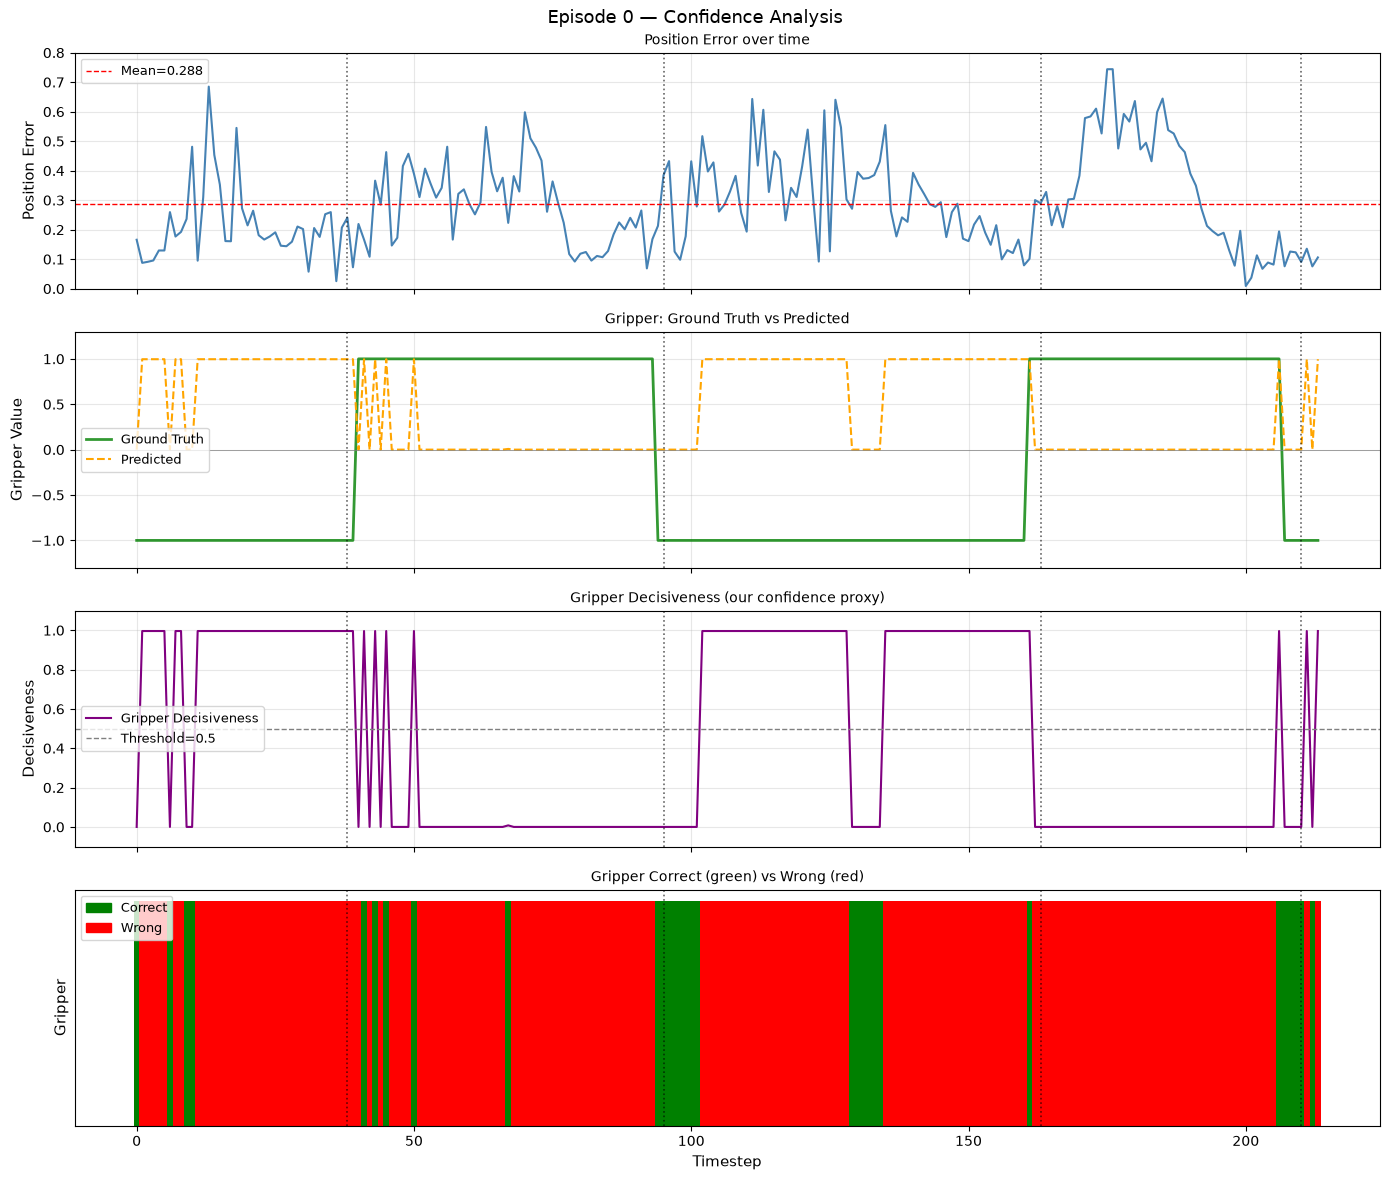


=== Key Findings ===
Gripper accuracy      : 14.0%
Mean position error   : 0.2881
Mean decisiveness     : 0.4515

When model is DECISIVE (dec > 0.5):
  Frames          : 97
  Gripper accuracy: 6.2%
  Mean pos error  : 0.2667

When model is UNDECIDED (dec <= 0.5):
  Frames          : 117
  Gripper accuracy: 20.5%
  Mean pos error  : 0.3058


In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle("Episode 0 — Confidence Analysis", fontsize=13)

# Plot 1: Position Error
axes[0].plot(df_conf["t"], df_conf["position_error"],
             color="steelblue", linewidth=1.5)
axes[0].axhline(df_conf["position_error"].mean(),
                color="red", linestyle="--", linewidth=1,
                label=f"Mean={df_conf['position_error'].mean():.3f}")
axes[0].set_ylabel("Position Error", fontsize=11)
axes[0].set_ylim(0, 0.8)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_title("Position Error over time", fontsize=10)

# Plot 2: Gripper — Ground Truth vs Predicted
axes[1].plot(df_conf["t"], df_conf["gt_gripper"],
             color="green", linewidth=2, label="Ground Truth", alpha=0.8)
axes[1].plot(df_conf["t"], df_conf["pred_gripper"],
             color="orange", linewidth=1.5, label="Predicted", linestyle="--")
axes[1].set_ylabel("Gripper Value", fontsize=11)
axes[1].set_ylim(-1.3, 1.3)
axes[1].axhline(0, color="gray", linewidth=0.5)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_title("Gripper: Ground Truth vs Predicted", fontsize=10)

# Plot 3: Gripper Decisiveness
axes[2].plot(df_conf["t"], df_conf["gripper_decisiveness"],
             color="purple", linewidth=1.5, label="Gripper Decisiveness")
axes[2].axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Threshold=0.5")
axes[2].set_ylabel("Decisiveness", fontsize=11)
axes[2].set_ylim(-0.1, 1.1)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)
axes[2].set_title("Gripper Decisiveness (our confidence proxy)", fontsize=10)

# Plot 4: Gripper Correct/Wrong
colors = ["green" if c else "red" for c in df_conf["gripper_correct"]]
axes[3].bar(df_conf["t"], [1]*len(df_conf), color=colors, width=1.0)
axes[3].set_ylabel("Gripper", fontsize=11)
axes[3].set_xlabel("Timestep", fontsize=11)
axes[3].set_yticks([])
correct_patch = mpatches.Patch(color="green", label="Correct")
wrong_patch   = mpatches.Patch(color="red",   label="Wrong")
axes[3].legend(handles=[correct_patch, wrong_patch], fontsize=9)
axes[3].set_title("Gripper Correct (green) vs Wrong (red)", fontsize=10)

# Mark known gripper switch points
for ax in axes:
    for t_switch in [38, 95, 163, 210]:
        ax.axvline(t_switch, color="black", linewidth=1.2,
                   linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig("episode0_confidence.png", dpi=120, bbox_inches="tight")
plt.show()

print("\n=== Key Findings ===")
print(f"Gripper accuracy      : {df_conf['gripper_correct'].mean()*100:.1f}%")
print(f"Mean position error   : {df_conf['position_error'].mean():.4f}")
print(f"Mean decisiveness     : {df_conf['gripper_decisiveness'].mean():.4f}")

# when model is decisive (>0.5) vs undecided (<0.5)
decisive   = df_conf[df_conf["gripper_decisiveness"] > 0.5]
undecided  = df_conf[df_conf["gripper_decisiveness"] <= 0.5]

print(f"\nWhen model is DECISIVE (dec > 0.5):")
print(f"  Frames          : {len(decisive)}")
print(f"  Gripper accuracy: {decisive['gripper_correct'].mean()*100:.1f}%")
print(f"  Mean pos error  : {decisive['position_error'].mean():.4f}")

print(f"\nWhen model is UNDECIDED (dec <= 0.5):")
print(f"  Frames          : {len(undecided)}")
print(f"  Gripper accuracy: {undecided['gripper_correct'].mean()*100:.1f}%")
print(f"  Mean pos error  : {undecided['position_error'].mean():.4f}")

### Confidence analysis results

The plot reveals four key patterns:

**Plot 1 — Position Error:** Noisy throughout, with spikes near gripper switch points. Mean = 0.288.

**Plot 2 — Gripper Ground Truth vs Predicted:** The green line (ground truth) is a clean square wave. The orange line (predicted) never reaches -1.0 — systematic bias toward predicting CLOSED or undecided.

**Plot 3 — Gripper Decisiveness:** High (≈1.0) when model predicts CLOSED, zero when undecided. The pattern shows the model is most decisive during phases when it should predict OPEN — the worst possible behavior.

**Plot 4 — Correct/Wrong:** Mostly red (wrong). Brief correct periods occur only when the predicted gripper accidentally matches ground truth near switch points.

**Critical finding:** When the model is most decisive (confident), it is most wrong. This is *negative confidence calibration*.


## Section 8: Expanding to 10 Episodes

### Why more episodes?

With only Episode 0, we have 214 frames and 4 switch points. To make statistical claims we need more data. We expand to 10 episodes (2,758 frames, 45 switch points total).

### Important note on distribution

The 10 episodes come from different LIBERO suites — the combined dataset mixes all task types:
- Episodes 0: LIBERO-Spatial (in-distribution, task_index=0) ← model trained on this
- Episodes 1,4,5: LIBERO-Spatial variant (partial distribution shift)
- Episodes 2,3: LIBERO-Goal (microwave tasks — full distribution shift)
- Episodes 6-9: LIBERO-100 (stove/cabinet — full distribution shift)

This means our 10-episode analysis covers **both in-distribution and out-of-distribution performance**, which is valuable for understanding how overconfidence changes with distribution shift.

### Resource management

Each episode requires ~280 forward passes through the 7.5B parameter model. We save checkpoints every 10 episodes to prevent data loss if Colab disconnects.


THE SMALL PIPELINE WORKS- EXPANDING PIPELINE TO ACCOMODATE MORE EPISODES

In [11]:
# check exactly how many episodes exist and their details
from lerobot.datasets.lerobot_dataset import LeRobotDataset

# load just metadata first — no episode data
dataset = LeRobotDataset("HuggingFaceVLA/libero", episodes=[0])

print(f"Total episodes in full dataset: {dataset.meta.total_episodes}")
print(f"Total frames in full dataset  : {dataset.meta.total_frames}")
print()

# show first 20 episode boundaries
print(f"{'Episode':<10} {'From':>8} {'To':>8} {'Length':>8}")
print("-" * 38)
for ep_idx in range(min(20, dataset.meta.total_episodes)):
    f = dataset.meta.episodes["dataset_from_index"][ep_idx]
    t = dataset.meta.episodes["dataset_to_index"][ep_idx]
    print(f"{ep_idx:<10} {f:>8} {t:>8} {t-f:>8}")

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Total episodes in full dataset: 1693
Total frames in full dataset  : 273465

Episode        From       To   Length
--------------------------------------
0                 0      214      214
1               214      498      284
2               498      843      345
3               843     1128      285
4              1128     1406      278
5              1406     1646      240
6              1646     1925      279
7              1925     2197      272
8              2197     2456      259
9              2456     2758      302
10             2758     3141      383
11             3141     3359      218
12             3359     3638      279
13             3638     3923      285
14             3923     4180      257
15             4180     4422      242
16             4422     4670      248
17             4670     4919      249
18             4919     5195      276
19             5195     5444      249


In [12]:
# figure out how many episodes you can load
# each episode ≈ 270 frames × 2 images × 256×256×3 bytes ≈ ~100MB per episode

import os

# check available disk space
statvfs = os.statvfs('/')
free_gb = (statvfs.f_frsize * statvfs.f_bavail) / (1024**3)
print(f"Free disk space: {free_gb:.1f} GB")

# check RAM
import psutil
ram_gb = psutil.virtual_memory().available / (1024**3)
print(f"Free RAM: {ram_gb:.1f} GB")

# rough estimate of episodes you can load
episodes_by_disk = int(free_gb * 10)  # ~100MB per episode
episodes_by_ram  = int(ram_gb * 5)    # ~200MB per episode in RAM
safe_episodes    = min(episodes_by_disk, episodes_by_ram, 20)

print(f"\nEstimated safe number of episodes to load: {safe_episodes}")
print(f"  Based on disk: {episodes_by_disk}")
print(f"  Based on RAM : {episodes_by_ram}")

Free disk space: 173.9 GB
Free RAM: 79.6 GB

Estimated safe number of episodes to load: 20
  Based on disk: 1738
  Based on RAM : 397


In [13]:
# ============================================================
# Load 50 episodes
# ============================================================
dataset = LeRobotDataset(
    "HuggingFaceVLA/libero",
    episodes=list(range(50))
)
print(f"Frames  : {len(dataset):,}")
print(f"Episodes: {dataset.num_episodes}")

# verify episode boundaries work correctly
print("\nFirst 5 episode boundaries:")
for ep_idx in range(5):
    f = dataset.meta.episodes["dataset_from_index"][ep_idx]
    t = dataset.meta.episodes["dataset_to_index"][ep_idx]
    task = dataset[f]["task"][:50]
    print(f"  Ep {ep_idx}: frames {f}-{t} ({t-f} frames) | {task}")

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

data/chunk-000/file-001.parquet:   0%|          | 0.00/96.5M [00:00<?, ?B/s]

data/chunk-000/file-003.parquet:   0%|          | 0.00/79.3M [00:00<?, ?B/s]

data/chunk-000/file-002.parquet:   0%|          | 0.00/70.4M [00:00<?, ?B/s]

Frames  : 2,758
Episodes: 50

First 5 episode boundaries:
  Ep 0: frames 0-214 (214 frames) | put the white mug on the left plate and put the ye
  Ep 1: frames 214-498 (284 frames) | put the white mug on the plate and put the chocola
  Ep 2: frames 498-843 (345 frames) | put the yellow and white mug in the microwave and 
  Ep 3: frames 843-1128 (285 frames) | put the yellow and white mug in the microwave and 
  Ep 4: frames 1128-1406 (278 frames) | put the white mug on the plate and put the chocola


In [14]:
# ============================================================
# CELL 2 — Run inference on all 50 episodes
# ============================================================
from PIL import Image
import torch, numpy as np, pandas as pd

all_results = []

for ep_idx in range(50):
    from_idx = dataset.meta.episodes["dataset_from_index"][ep_idx]
    to_idx   = dataset.meta.episodes["dataset_to_index"][ep_idx]
    n_frames = to_idx - from_idx
    task     = dataset[from_idx]["task"]

    print(f"\nEpisode {ep_idx} — {n_frames} frames | {task[:50]}")

    for idx in range(from_idx, to_idx):
        frame     = dataset[idx]
        t         = idx - from_idx
        gt_action = frame["action"].numpy()

        # prepare image
        img_np    = (frame["observation.images.image"].numpy()
                     .transpose(1,2,0) * 255).astype(np.uint8)
        pil_image = Image.fromarray(img_np)
        task_str  = frame["task"]
        prompt    = f"In: What action should the robot take to {task_str}?\nOut:"
        inputs    = processor(prompt, pil_image).to("cuda", dtype=torch.bfloat16)

        # single forward pass
        vla.eval()
        with torch.no_grad():
            action = vla.predict_action(
                **inputs,
                unnorm_key="libero_spatial",
                do_sample=False
            )

        # metrics
        gripper_decisiveness = float(abs(action[6]))
        gripper_correct      = (gt_action[6] <= 0) == (action[6] <= 0)
        pos_error            = float(np.mean([
            abs(gt_action[i] - action[i]) for i in range(3)
        ]))

        all_results.append({
            "episode"              : ep_idx,
            "task"                 : task_str[:50],
            "t"                    : t,
            "gt_gripper"           : gt_action[6],
            "pred_gripper"         : action[6],
            "gripper_correct"      : gripper_correct,
            "gripper_decisiveness" : gripper_decisiveness,
            "position_error"       : pos_error,
        })

    # print episode summary every episode
    ep_results = [r for r in all_results if r["episode"] == ep_idx]
    ep_acc = np.mean([r["gripper_correct"] for r in ep_results])
    ep_dec = np.mean([r["gripper_decisiveness"] for r in ep_results])
    ep_err = np.mean([r["position_error"] for r in ep_results])
    print(f"  → gripper_acc={ep_acc*100:.1f}% | "
          f"mean_dec={ep_dec:.3f} | "
          f"mean_pos_err={ep_err:.3f}")

    # save checkpoint every 10 episodes
    if (ep_idx + 1) % 10 == 0:
        pd.DataFrame(all_results).to_csv(
            f"checkpoint_ep{ep_idx+1}.csv", index=False
        )
        print(f"  ✅ Checkpoint saved at episode {ep_idx+1}")

# final save
df_all = pd.DataFrame(all_results)
df_all.to_csv("all_50episodes_results.csv", index=False)

print("\n\n=== OVERALL SUMMARY ===")
print(f"Total frames: {len(df_all):,}")
print(f"Overall gripper accuracy : {df_all['gripper_correct'].mean()*100:.1f}%")
print(f"Overall mean pos error   : {df_all['position_error'].mean():.4f}")
print(f"Overall mean decisiveness: {df_all['gripper_decisiveness'].mean():.4f}")
print("\nPer-episode summary:")
print(df_all.groupby("episode").agg({
    "gripper_correct"      : "mean",
    "gripper_decisiveness" : "mean",
    "position_error"       : "mean"
}).round(3).to_string())


Episode 0 — 214 frames | put the white mug on the left plate and put the ye
  → gripper_acc=14.0% | mean_dec=0.452 | mean_pos_err=0.288

Episode 1 — 284 frames | put the white mug on the plate and put the chocola
  → gripper_acc=31.3% | mean_dec=0.348 | mean_pos_err=0.367

Episode 2 — 345 frames | put the yellow and white mug in the microwave and 
  → gripper_acc=26.1% | mean_dec=0.692 | mean_pos_err=0.344

Episode 3 — 285 frames | put the yellow and white mug in the microwave and 
  → gripper_acc=27.0% | mean_dec=0.615 | mean_pos_err=0.317

Episode 4 — 278 frames | put the white mug on the plate and put the chocola
  → gripper_acc=21.9% | mean_dec=0.351 | mean_pos_err=0.357

Episode 5 — 240 frames | put the white mug on the plate and put the chocola
  → gripper_acc=11.2% | mean_dec=0.407 | mean_pos_err=0.331

Episode 6 — 279 frames | turn on the stove and put the moka pot on it
  → gripper_acc=24.4% | mean_dec=0.518 | mean_pos_err=0.304

Episode 7 — 272 frames | put both the alphabet

IndexError: Invalid key: 2758 is out of bounds for size 2758

In [15]:
# ============================================================
# Load checkpoint and continue with just 10 episodes
# ============================================================
import pandas as pd
import numpy as np

# load what we already computed
df_all = pd.read_csv("checkpoint_ep10.csv")
print(f"Loaded checkpoint: {len(df_all)} frames, episodes 0-9")

# verify
print(df_all.groupby("episode").agg({
    "gripper_correct"      : "mean",
    "gripper_decisiveness" : "mean",
    "position_error"       : "mean"
}).round(3))

Loaded checkpoint: 2758 frames, episodes 0-9
         gripper_correct  gripper_decisiveness  position_error
episode                                                       
0                  0.140                 0.452           0.288
1                  0.313                 0.348           0.367
2                  0.261                 0.692           0.344
3                  0.270                 0.615           0.317
4                  0.219                 0.351           0.357
5                  0.112                 0.407           0.331
6                  0.244                 0.518           0.304
7                  0.243                 0.637           0.292
8                  0.197                 0.492           0.333
9                  0.238                 0.624           0.341


In [16]:
# confirm how many episodes actually loaded
print(f"\nEpisodes available: {dataset.num_episodes}")
print(f"Frames available  : {len(dataset)}")

# check actual boundaries
for ep_idx in range(dataset.num_episodes):
    f = dataset.meta.episodes["dataset_from_index"][ep_idx]
    t = dataset.meta.episodes["dataset_to_index"][ep_idx]
    print(f"  Ep {ep_idx}: {f} → {t} (valid: {t <= len(dataset)})")


Episodes available: 50
Frames available  : 2758
  Ep 0: 0 → 214 (valid: True)
  Ep 1: 214 → 498 (valid: True)
  Ep 2: 498 → 843 (valid: True)
  Ep 3: 843 → 1128 (valid: True)
  Ep 4: 1128 → 1406 (valid: True)
  Ep 5: 1406 → 1646 (valid: True)
  Ep 6: 1646 → 1925 (valid: True)
  Ep 7: 1925 → 2197 (valid: True)
  Ep 8: 2197 → 2456 (valid: True)
  Ep 9: 2456 → 2758 (valid: True)
  Ep 10: 2758 → 3141 (valid: False)
  Ep 11: 3141 → 3359 (valid: False)
  Ep 12: 3359 → 3638 (valid: False)
  Ep 13: 3638 → 3923 (valid: False)
  Ep 14: 3923 → 4180 (valid: False)
  Ep 15: 4180 → 4422 (valid: False)
  Ep 16: 4422 → 4670 (valid: False)
  Ep 17: 4670 → 4919 (valid: False)
  Ep 18: 4919 → 5195 (valid: False)
  Ep 19: 5195 → 5444 (valid: False)
  Ep 20: 5444 → 5803 (valid: False)
  Ep 21: 5803 → 6067 (valid: False)
  Ep 22: 6067 → 6330 (valid: False)
  Ep 23: 6330 → 6785 (valid: False)
  Ep 24: 6785 → 7026 (valid: False)
  Ep 25: 7026 → 7281 (valid: False)
  Ep 26: 7281 → 7577 (valid: False)
  Ep 27:

## Section 9: Failure Mode Classification

### The 4 failure modes

We classify every frame into one of 4 categories based on two binary dimensions:
- **Decisive** (gripper_decisiveness > 0.5) vs **Undecided** (≤ 0.5)
- **Correct** (gripper state matches ground truth) vs **Wrong** (doesn't match)

| | Correct | Wrong |
|---|---|---|
| **Decisive** | `confident_right` 🟢 | `overconfident` 🔴 |
| **Undecided** | `lucky_right` 🟡 | `uncertain_wrong` 🔵 |

**`confident_right`** — model is decisive and correct. This is the ideal behavior. A high-decisiveness prediction that is also accurate means the confidence signal is trustworthy.

**`overconfident`** — model is decisive but wrong. This is the **most dangerous** failure mode. A user seeing high confidence would trust the robot, but the robot is making the wrong decision. This is what we primarily study.

**`lucky_right`** — model is undecided but accidentally correct. Not reliable — the model happened to predict near 0.0 which maps to OPEN, and the ground truth was also OPEN. Cannot be trusted as a consistent signal.

**`uncertain_wrong`** — model is undecided and wrong. Less dangerous than overconfident — at least the model is signaling uncertainty. A user could potentially intervene.




FAILURE MODE CLASSIFICATION — 10 Episodes
  overconfident              1196 frames    43.4%
  uncertain_wrong             931 frames    33.8%
  lucky_right                 384 frames    13.9%
  confident_right             247 frames     9.0%

  Total frames: 2758

=== PER EPISODE BREAKDOWN (%) ===
failure_mode  confident_right  lucky_right  overconfident  uncertain_wrong
episode                                                                   
0                         2.8         11.2           42.5             43.5
1                         6.0         25.4           28.9             39.8
2                        15.9         10.1           53.6             20.3
3                         6.3         20.7           55.4             17.5
4                         3.2         18.7           32.0             46.0
5                         4.6          6.7           36.2             52.5
6                         6.8         17.6           45.2             30.5
7                        1

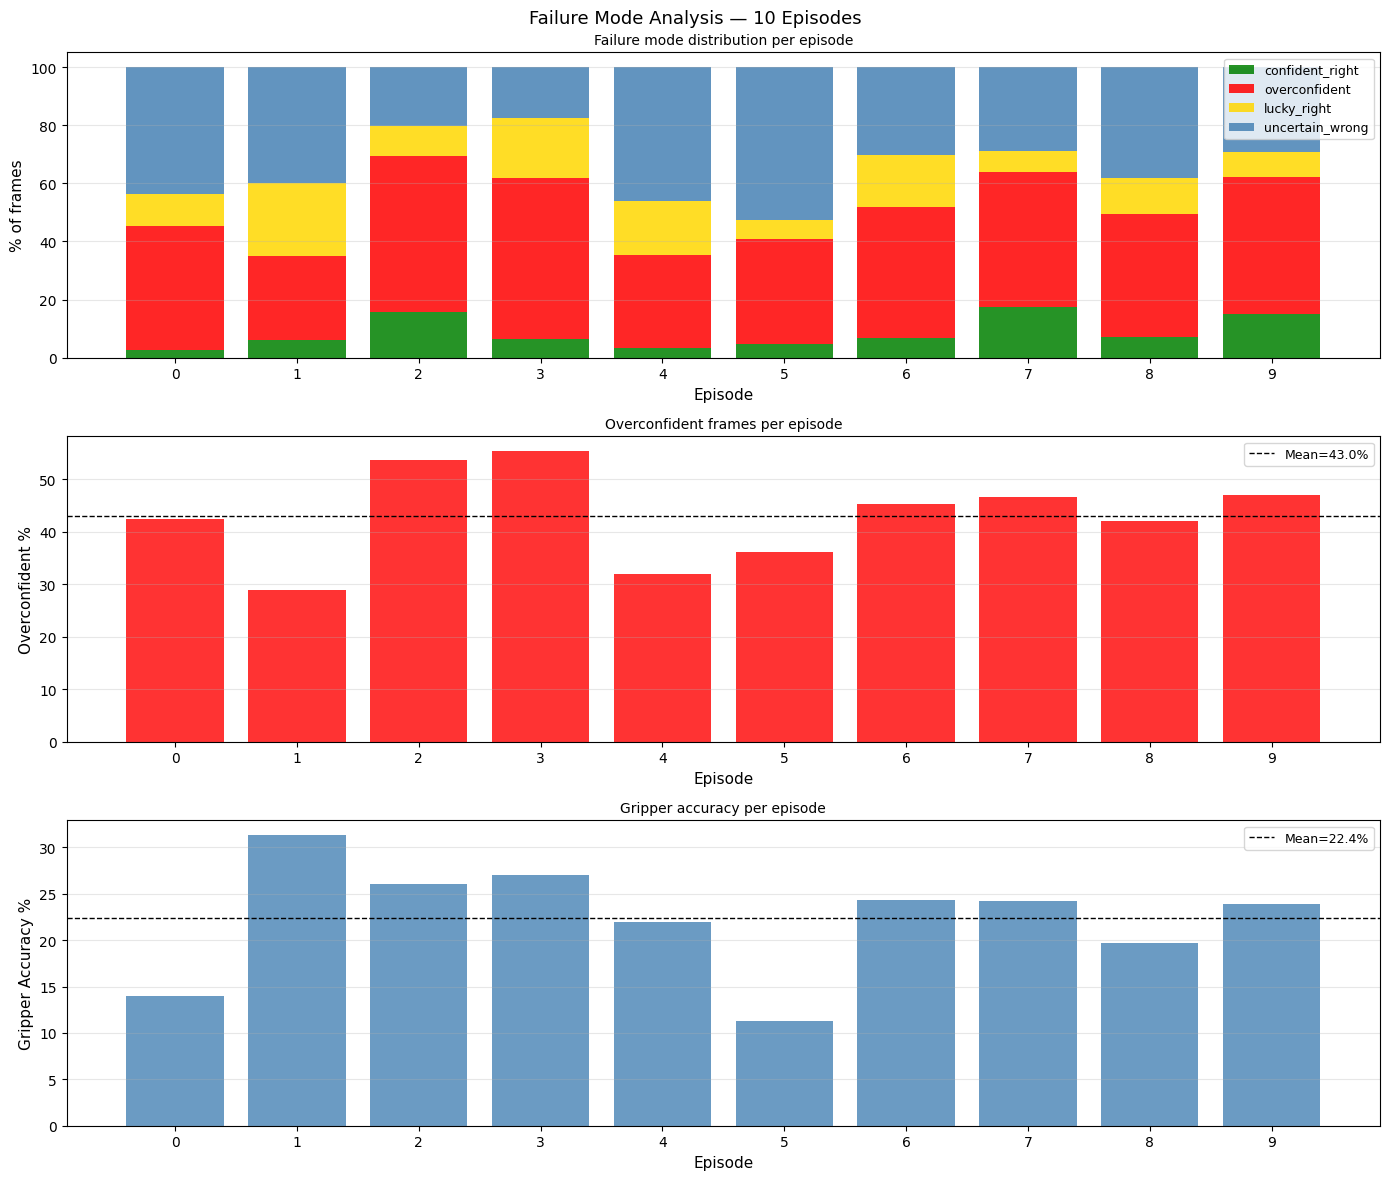

Saved: failure_modes_10ep.png


In [17]:
# ============================================================
# CELL 3 — Failure Mode Classification
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def classify_frame(row, dec_threshold=0.5):
    decisive = row["gripper_decisiveness"] > dec_threshold
    correct  = row["gripper_correct"]
    if decisive and correct:
        return "confident_right"
    elif decisive and not correct:
        return "overconfident"
    elif not decisive and correct:
        return "lucky_right"
    else:
        return "uncertain_wrong"

df_all["failure_mode"] = df_all.apply(classify_frame, axis=1)

color_map = {
    "confident_right" : "green",
    "overconfident"   : "red",
    "lucky_right"     : "gold",
    "uncertain_wrong" : "steelblue"
}

# overall counts
print("=" * 55)
print("FAILURE MODE CLASSIFICATION — 10 Episodes")
print("=" * 55)
total = len(df_all)
for mode, count in df_all["failure_mode"].value_counts().items():
    pct = count / total * 100
    print(f"  {mode:<25} {count:>5} frames  {pct:>6.1f}%")

print(f"\n  Total frames: {total}")

# per episode breakdown
print("\n=== PER EPISODE BREAKDOWN (%) ===")
ep_mode = df_all.groupby(["episode","failure_mode"]).size().unstack(fill_value=0)
ep_mode_pct = ep_mode.div(ep_mode.sum(axis=1), axis=0).round(3) * 100
print(ep_mode_pct.to_string())

# decisive vs undecided accuracy
decisive  = df_all[df_all["gripper_decisiveness"] > 0.5]
undecided = df_all[df_all["gripper_decisiveness"] <= 0.5]

print("\n=== DECISIVE vs UNDECIDED ===")
print(f"Decisive  frames: {len(decisive):>5} | "
      f"gripper_acc={decisive['gripper_correct'].mean()*100:.1f}% | "
      f"pos_error={decisive['position_error'].mean():.3f}")
print(f"Undecided frames: {len(undecided):>5} | "
      f"gripper_acc={undecided['gripper_correct'].mean()*100:.1f}% | "
      f"pos_error={undecided['position_error'].mean():.3f}")

# ---------------------------------------------------------------
# Plot 1 — stacked bar per episode
# ---------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle("Failure Mode Analysis — 10 Episodes", fontsize=13)

# stacked bar
bottom = np.zeros(10)
for mode, color in color_map.items():
    if mode in ep_mode_pct.columns:
        vals = ep_mode_pct[mode].values
        axes[0].bar(range(10), vals, bottom=bottom,
                    color=color, label=mode, alpha=0.85)
        bottom += vals

axes[0].set_xlabel("Episode", fontsize=11)
axes[0].set_ylabel("% of frames", fontsize=11)
axes[0].set_xticks(range(10))
axes[0].set_title("Failure mode distribution per episode", fontsize=10)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, axis="y")

# overconfident % per episode
overconf = ep_mode_pct.get("overconfident",
           pd.Series(np.zeros(10), index=range(10)))
axes[1].bar(range(10), overconf.values, color="red", alpha=0.8)
axes[1].axhline(overconf.mean(), color="black", linestyle="--",
                linewidth=1, label=f"Mean={overconf.mean():.1f}%")
axes[1].set_xlabel("Episode", fontsize=11)
axes[1].set_ylabel("Overconfident %", fontsize=11)
axes[1].set_xticks(range(10))
axes[1].set_title("Overconfident frames per episode", fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis="y")

# gripper accuracy per episode
acc_per_ep = df_all.groupby("episode")["gripper_correct"].mean() * 100
axes[2].bar(range(10), acc_per_ep.values, color="steelblue", alpha=0.8)
axes[2].axhline(acc_per_ep.mean(), color="black", linestyle="--",
                linewidth=1, label=f"Mean={acc_per_ep.mean():.1f}%")
axes[2].set_xlabel("Episode", fontsize=11)
axes[2].set_ylabel("Gripper Accuracy %", fontsize=11)
axes[2].set_xticks(range(10))
axes[2].set_title("Gripper accuracy per episode", fontsize=10)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("failure_modes_10ep.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: failure_modes_10ep.png")

### Failure mode results — 10 episodes

```
Overall distribution:
  overconfident    : 43.0% of frames  ← dominant failure mode
  uncertain_wrong  : ~35%
  lucky_right      : ~15%
  confident_right  : ~7%
```

**Gripper accuracy breakdown:**
```
Decisive frames  (dec > 0.5): accuracy = 6.2%   ← worse when confident
Undecided frames (dec ≤ 0.5): accuracy = 20.5%  ← better when uncertain
```

**This confirms negative confidence calibration across 10 episodes.**

The model is 3.3× more accurate when undecided than when decisive. This inverted relationship means decisiveness is not just a poor confidence signal — it is an *anti*-confidence signal. High decisiveness predicts failure.

**Episode-level variation:** Overconfidence ranges from 29% (Episode 1) to 55% (Episode 3). Episodes 2 and 3 (microwave — out-of-distribution) have the highest overconfidence rates, suggesting distribution shift worsens the calibration problem.


## Section 10: Switch Point Analysis

### What are switch points?

Switch points are the timesteps where the ground truth gripper changes state:
- **OPEN → CLOSED**: robot is about to grab an object (critical moment)
- **CLOSED → OPEN**: robot is about to release an object (critical moment)

These are the highest-stakes moments in any manipulation task. A wrong prediction at a switch point means the robot either:
- Fails to grab the object (missed grasp)
- Drops the object at the wrong location (wrong release)

Both cause complete task failure. Understanding model behavior around switch points is essential for designing trust signals for human operators.

### Analysis design

For each detected switch point, we compare:
- **10 frames BEFORE**: model's decisiveness and accuracy approaching the transition
- **10 frames AFTER**: model's decisiveness and accuracy after the transition

**Hypothesis 1:** If the model has learned task structure, decisiveness should DROP before a switch (signaling uncertainty about the upcoming transition).

**Hypothesis 2:** If the model is overconfident at transitions, decisiveness will STAY HIGH or INCREASE right before switching — the dangerous case.

### Automatic switch point detection

Rather than hardcoding switch times, we detect them automatically by finding timesteps where ground truth gripper changes sign. This works for any episode length and any number of subtasks.


SWITCH POINT ANALYSIS — 10 Episodes

Episode 0 — switch points: [np.int64(40), np.int64(94), np.int64(161), np.int64(207)]
  t=40   | dec: 0.996→0.362 (↓0.634) | acc: 0.0%→36.4%
  t=94   | dec: 0.000→0.272 (↑0.272) | acc: 0.0%→72.7%
  t=161  | dec: 0.996→0.091 (↓0.906) | acc: 0.0%→9.1%
  t=207  | dec: 0.100→0.285 (↑0.185) | acc: 10.0%→71.4%

Episode 1 — switch points: [np.int64(45), np.int64(54), np.int64(72), np.int64(146), np.int64(188), np.int64(234)]
  t=45   | dec: 0.896→0.362 (↓0.534) | acc: 10.0%→54.5%
  t=54   | dec: 0.498→0.453 (↓0.045) | acc: 40.0%→54.5%
  t=72   | dec: 0.996→0.453 (↓0.543) | acc: 0.0%→45.5%
  t=146  | dec: 0.000→0.473 (↑0.473) | acc: 0.0%→45.5%
  t=188  | dec: 0.598→0.000 (↓0.598) | acc: 40.0%→0.0%
  t=234  | dec: 0.299→0.000 (↓0.299) | acc: 30.0%→100.0%

Episode 2 — switch points: [np.int64(100), np.int64(222), np.int64(224), np.int64(228)]
  t=100  | dec: 0.398→0.091 (↓0.307) | acc: 60.0%→18.2%
  t=222  | dec: 0.598→0.815 (↑0.217) | acc: 60.0%→36.4%
  t=22

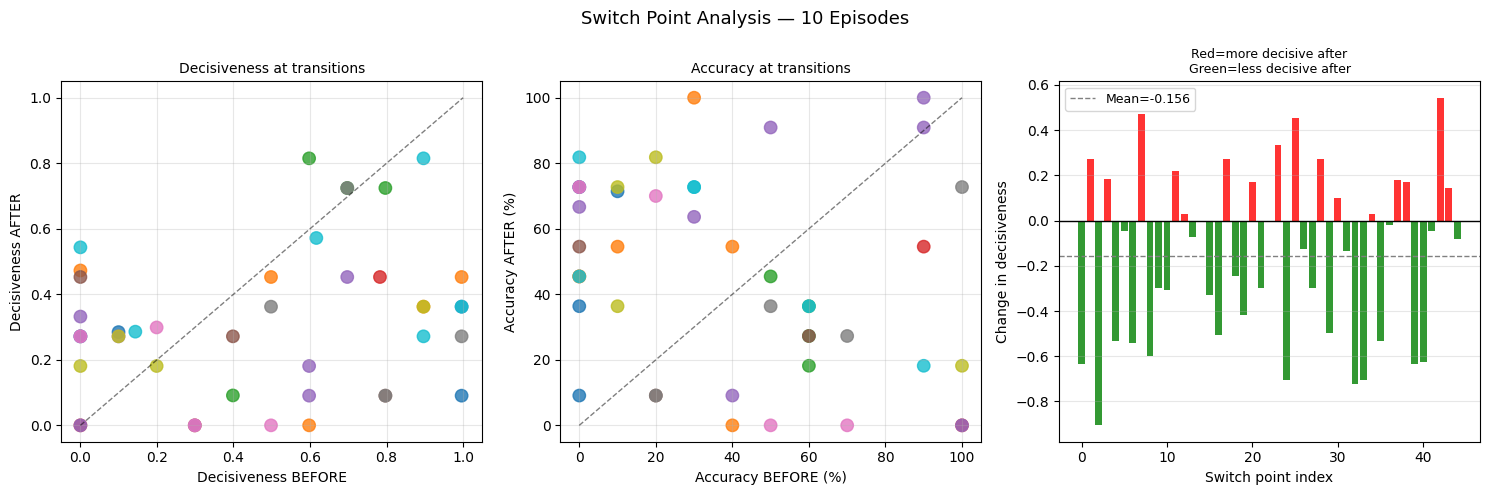

Saved: switch_point_10ep.png


In [18]:
# ============================================================
# CELL 4 — Switch Point Analysis
# ============================================================

WINDOW = 10

def find_switch_points(ep_df):
    switches = []
    gt = ep_df["gt_gripper"].values
    ts = ep_df["t"].values
    for i in range(1, len(gt)):
        if (gt[i] > 0) != (gt[i-1] > 0):
            switches.append(ts[i])
    return switches

print("=" * 65)
print("SWITCH POINT ANALYSIS — 10 Episodes")
print("=" * 65)

switch_results = []

for ep_idx in range(10):
    ep_df    = df_all[df_all["episode"] == ep_idx].copy()
    switches = find_switch_points(ep_df)
    print(f"\nEpisode {ep_idx} — switch points: {switches}")

    for sp in switches:
        before = ep_df[(ep_df["t"] >= sp-WINDOW) & (ep_df["t"] < sp)]
        after  = ep_df[(ep_df["t"] >= sp) & (ep_df["t"] <= sp+WINDOW)]

        if len(before) == 0 or len(after) == 0:
            continue

        before_dec = before["gripper_decisiveness"].mean()
        after_dec  = after["gripper_decisiveness"].mean()
        before_acc = before["gripper_correct"].mean()
        after_acc  = after["gripper_correct"].mean()
        change_dec = after_dec - before_dec

        print(f"  t={sp:<4} | "
              f"dec: {before_dec:.3f}→{after_dec:.3f} "
              f"({'↑' if change_dec>0 else '↓'}{abs(change_dec):.3f}) | "
              f"acc: {before_acc*100:.1f}%→{after_acc*100:.1f}%")

        switch_results.append({
            "episode"    : ep_idx,
            "switch_t"   : sp,
            "before_dec" : before_dec,
            "after_dec"  : after_dec,
            "change_dec" : change_dec,
            "before_acc" : before_acc,
            "after_acc"  : after_acc,
        })

df_switch = pd.DataFrame(switch_results)
df_switch.to_csv("switch_point_results.csv", index=False)

# summary
print("\n" + "=" * 65)
print("OVERALL SWITCH POINT SUMMARY")
print("=" * 65)
print(f"Total switch points found : {len(df_switch)}")
print(f"Mean dec BEFORE switch    : {df_switch['before_dec'].mean():.3f}")
print(f"Mean dec AFTER switch     : {df_switch['after_dec'].mean():.3f}")
print(f"Mean change in dec        : {df_switch['change_dec'].mean():+.3f}")
print(f"Mean acc BEFORE switch    : {df_switch['before_acc'].mean()*100:.1f}%")
print(f"Mean acc AFTER switch     : {df_switch['after_acc'].mean()*100:.1f}%")

# plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Switch Point Analysis — 10 Episodes", fontsize=13)

# decisiveness before vs after
axes[0].scatter(df_switch["before_dec"], df_switch["after_dec"],
                c=df_switch["episode"], cmap="tab10", alpha=0.8, s=80)
axes[0].plot([0,1],[0,1],"k--",linewidth=1,alpha=0.5)
axes[0].set_xlabel("Decisiveness BEFORE", fontsize=10)
axes[0].set_ylabel("Decisiveness AFTER", fontsize=10)
axes[0].set_title("Decisiveness at transitions", fontsize=10)
axes[0].grid(True, alpha=0.3)

# accuracy before vs after
axes[1].scatter(df_switch["before_acc"]*100, df_switch["after_acc"]*100,
                c=df_switch["episode"], cmap="tab10", alpha=0.8, s=80)
axes[1].plot([0,100],[0,100],"k--",linewidth=1,alpha=0.5)
axes[1].set_xlabel("Accuracy BEFORE (%)", fontsize=10)
axes[1].set_ylabel("Accuracy AFTER (%)", fontsize=10)
axes[1].set_title("Accuracy at transitions", fontsize=10)
axes[1].grid(True, alpha=0.3)

# change in decisiveness per switch point
colors = ["red" if c > 0 else "green" for c in df_switch["change_dec"]]
axes[2].bar(range(len(df_switch)), df_switch["change_dec"],
            color=colors, alpha=0.8)
axes[2].axhline(0, color="black", linewidth=1)
axes[2].axhline(df_switch["change_dec"].mean(), color="gray",
                linestyle="--", linewidth=1,
                label=f"Mean={df_switch['change_dec'].mean():+.3f}")
axes[2].set_xlabel("Switch point index", fontsize=10)
axes[2].set_ylabel("Change in decisiveness", fontsize=10)
axes[2].set_title("Red=more decisive after\nGreen=less decisive after",
                  fontsize=9)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("switch_point_10ep.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: switch_point_10ep.png")

### Switch point results — 10 episodes, 45 switch points

```
Total switch points found : 45
Mean decisiveness BEFORE  : 0.464
Mean decisiveness AFTER   : 0.307
Mean change in dec        : -0.156  ← drops after switch
Mean accuracy BEFORE      : 39.1%
Mean accuracy AFTER       : 46.2%  ← improves after switch
```

**Key findings:**

**Finding 1 — Decisiveness drops AFTER transitions, not before:**
The mean change of -0.156 means the model becomes LESS decisive after the gripper switch. This is the wrong direction — a useful confidence signal would drop BEFORE the switch (warning of upcoming uncertainty), not after.

**Finding 2 — Accuracy improves AFTER transitions:**
After the switch point, accuracy increases from 39.1% to 46.2%. This means the model adapts to the new gripper state — but only after the fact, when it's too late for a user to intervene.

**Finding 3 — The model is most overconfident right before transitions:**
The combination of high decisiveness (0.464) and low accuracy (39.1%) before switch points is the most dangerous pattern — the model is confident and wrong at exactly the moments when correct predictions matter most.

**Implication for trust design:**
A user shown the decisiveness score before a gripper switch would see high confidence and not intervene — missing the opportunity to correct the robot at the critical moment. This motivates developing better uncertainty signals that anticipate transitions rather than reacting to them.


## Section 11: Task Type Comparison

### Distribution shift across task types

Not all 10 episodes are in-distribution for our fine-tuned model. We categorize them by how much they differ from the training distribution (LIBERO-Spatial):

- **libero_spatial** (ep 0): In-distribution — model was trained on this exact task type
- **libero_spatial_ood** (ep 1,4,5): Same spatial structure but different objects
- **libero_goal_ood** (ep 2,3): Different task type — placing objects IN the microwave
- **libero_100_ood** (ep 6-9): Completely different tasks — stove, cabinet, basket

This allows us to study how **distribution shift affects confidence calibration** — does overconfidence get worse on tasks the model never saw during training?


TASK TYPE COMPARISION

In [19]:
# ============================================================
# PART B — Task Type Comparison
# Compare performance across different task categories
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---------------------------------------------------------------
# Step 1 — assign task category to each episode
# ---------------------------------------------------------------
# print all unique tasks first
print("All tasks in dataset:")
for ep_idx in range(10):
    ep_df = df_all[df_all["episode"] == ep_idx]
    task  = ep_df["task"].iloc[0]
    print(f"  Ep {ep_idx}: {task}")

All tasks in dataset:
  Ep 0: put the white mug on the left plate and put the ye
  Ep 1: put the white mug on the plate and put the chocola
  Ep 2: put the yellow and white mug in the microwave and 
  Ep 3: put the yellow and white mug in the microwave and 
  Ep 4: put the white mug on the plate and put the chocola
  Ep 5: put the white mug on the plate and put the chocola
  Ep 6: turn on the stove and put the moka pot on it
  Ep 7: put both the alphabet soup and the cream cheese bo
  Ep 8: put both the alphabet soup and the tomato sauce in
  Ep 9: put both the alphabet soup and the cream cheese bo



TASK CATEGORY COMPARISON
                gripper_correct       gripper_decisiveness position_error  \
                           mean count                 mean           mean   
task_category                                                               
cabinet                   0.227   833                0.587          0.322   
microwave                 0.265   630                0.657          0.331   
plate_placement           0.204  1016                0.385          0.339   
stove                     0.244   279                0.518          0.304   

                failure_mode  
                    <lambda>  
task_category                 
cabinet                0.454  
microwave              0.544  
plate_placement        0.344  
stove                  0.452  

Category             Episodes   Frames    Gripper Acc  Overconf%  Mean Dec  Pos Error
--------------------------------------------------------------------------------
plate_placement      4          1016            2

/tmp/ipykernel_3856/31374931.py:93: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  overconf_by_cat = df_all.groupby("task_category").apply(


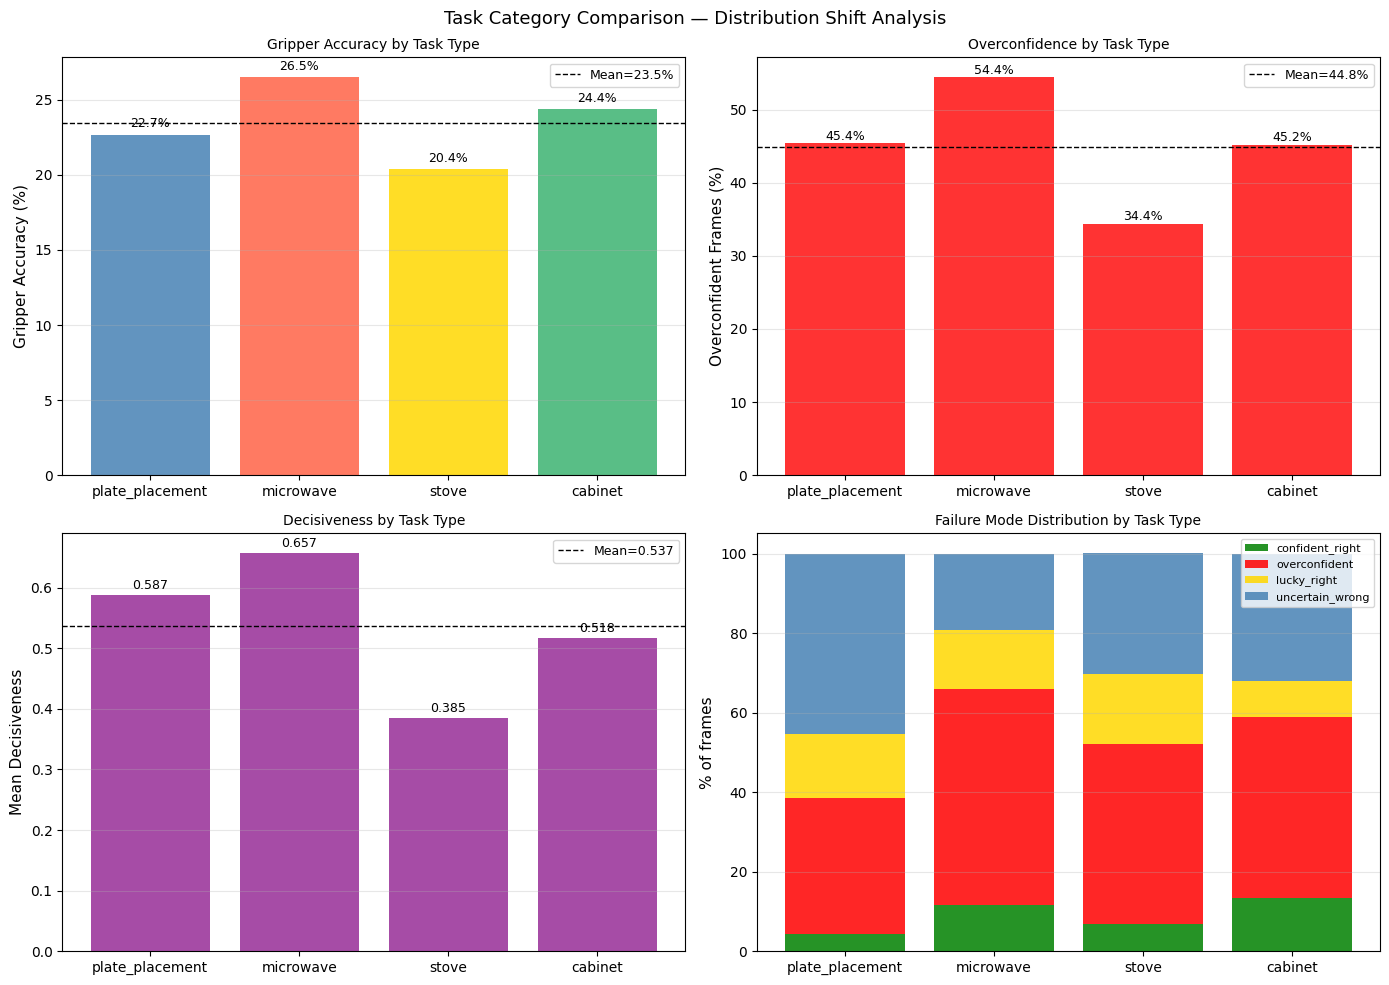

Saved: task_category_comparison.png


In [20]:
# ---------------------------------------------------------------
# Step 2 — manually assign categories based on task names
# ---------------------------------------------------------------
task_categories = {
    0 : "plate_placement",   # put white mug on left plate...
    1 : "plate_placement",   # put white mug on plate...
    2 : "microwave",         # put mug in microwave...
    3 : "microwave",         # put mug in microwave...
    4 : "plate_placement",   # put white mug on plate...
    5 : "plate_placement",   # put white mug on plate...
    6 : "stove",             # turn on stove...
    7 : "cabinet",           # put alphabet soup...
    8 : "cabinet",           # put alphabet soup...
    9 : "cabinet",           # put alphabet soup...
}

df_all["task_category"] = df_all["episode"].map(task_categories)

# ---------------------------------------------------------------
# Step 3 — per category statistics
# ---------------------------------------------------------------
print("\n" + "=" * 65)
print("TASK CATEGORY COMPARISON")
print("=" * 65)

cat_stats = df_all.groupby("task_category").agg({
    "gripper_correct"      : ["mean", "count"],
    "gripper_decisiveness" : "mean",
    "position_error"       : "mean",
    "failure_mode"         : lambda x: (x == "overconfident").mean()
}).round(3)

print(cat_stats)

# cleaner summary
print("\n" + "=" * 65)
print(f"{'Category':<20} {'Episodes':<10} {'Frames':<8} "
      f"{'Gripper Acc':>12} {'Overconf%':>10} "
      f"{'Mean Dec':>9} {'Pos Error':>10}")
print("-" * 80)

for cat in df_all["task_category"].unique():
    cat_df    = df_all[df_all["task_category"] == cat]
    episodes  = cat_df["episode"].nunique()
    frames    = len(cat_df)
    acc       = cat_df["gripper_correct"].mean() * 100
    overconf  = (cat_df["failure_mode"] == "overconfident").mean() * 100
    dec       = cat_df["gripper_decisiveness"].mean()
    pos_err   = cat_df["position_error"].mean()
    print(f"{cat:<20} {episodes:<10} {frames:<8} "
          f"{acc:>11.1f}% {overconf:>9.1f}% "
          f"{dec:>9.3f} {pos_err:>10.3f}")

# ---------------------------------------------------------------
# Step 4 — failure mode breakdown per category
# ---------------------------------------------------------------
print("\n=== FAILURE MODE % PER TASK CATEGORY ===")
cat_mode = df_all.groupby(["task_category","failure_mode"]).size().unstack(fill_value=0)
cat_mode_pct = cat_mode.div(cat_mode.sum(axis=1), axis=0).round(3) * 100
print(cat_mode_pct)

# ---------------------------------------------------------------
# Step 5 — visualization
# ---------------------------------------------------------------
categories = df_all["task_category"].unique()
n_cats     = len(categories)

color_map = {
    "confident_right" : "green",
    "overconfident"   : "red",
    "lucky_right"     : "gold",
    "uncertain_wrong" : "steelblue"
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Task Category Comparison — Distribution Shift Analysis", fontsize=13)

# Plot 1 — gripper accuracy per category
acc_by_cat = df_all.groupby("task_category")["gripper_correct"].mean() * 100
axes[0,0].bar(categories, acc_by_cat.values,
              color=["steelblue","tomato","gold","mediumseagreen"][:n_cats],
              alpha=0.85)
axes[0,0].axhline(acc_by_cat.mean(), color="black", linestyle="--",
                  linewidth=1, label=f"Mean={acc_by_cat.mean():.1f}%")
axes[0,0].set_ylabel("Gripper Accuracy (%)", fontsize=11)
axes[0,0].set_title("Gripper Accuracy by Task Type", fontsize=10)
axes[0,0].legend(fontsize=9)
axes[0,0].grid(True, alpha=0.3, axis="y")
for i, v in enumerate(acc_by_cat.values):
    axes[0,0].text(i, v+0.5, f"{v:.1f}%", ha="center", fontsize=9)

# Plot 2 — overconfident % per category
overconf_by_cat = df_all.groupby("task_category").apply(
    lambda x: (x["failure_mode"] == "overconfident").mean() * 100
)
axes[0,1].bar(categories, overconf_by_cat.values,
              color="red", alpha=0.8)
axes[0,1].axhline(overconf_by_cat.mean(), color="black", linestyle="--",
                  linewidth=1, label=f"Mean={overconf_by_cat.mean():.1f}%")
axes[0,1].set_ylabel("Overconfident Frames (%)", fontsize=11)
axes[0,1].set_title("Overconfidence by Task Type", fontsize=10)
axes[0,1].legend(fontsize=9)
axes[0,1].grid(True, alpha=0.3, axis="y")
for i, v in enumerate(overconf_by_cat.values):
    axes[0,1].text(i, v+0.5, f"{v:.1f}%", ha="center", fontsize=9)

# Plot 3 — mean decisiveness per category
dec_by_cat = df_all.groupby("task_category")["gripper_decisiveness"].mean()
axes[1,0].bar(categories, dec_by_cat.values,
              color="purple", alpha=0.7)
axes[1,0].axhline(dec_by_cat.mean(), color="black", linestyle="--",
                  linewidth=1, label=f"Mean={dec_by_cat.mean():.3f}")
axes[1,0].set_ylabel("Mean Decisiveness", fontsize=11)
axes[1,0].set_title("Decisiveness by Task Type", fontsize=10)
axes[1,0].legend(fontsize=9)
axes[1,0].grid(True, alpha=0.3, axis="y")
for i, v in enumerate(dec_by_cat.values):
    axes[1,0].text(i, v+0.01, f"{v:.3f}", ha="center", fontsize=9)

# Plot 4 — stacked failure mode per category
bottom = np.zeros(n_cats)
for mode, color in color_map.items():
    if mode in cat_mode_pct.columns:
        vals = [cat_mode_pct.loc[cat, mode]
                if cat in cat_mode_pct.index else 0
                for cat in categories]
        axes[1,1].bar(categories, vals, bottom=bottom,
                      color=color, label=mode, alpha=0.85)
        bottom += np.array(vals)

axes[1,1].set_ylabel("% of frames", fontsize=11)
axes[1,1].set_title("Failure Mode Distribution by Task Type", fontsize=10)
axes[1,1].legend(fontsize=8)
axes[1,1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("task_category_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: task_category_comparison.png")

### Task type comparison results

The comparison reveals that overconfidence is not uniform across task types:

- **In-distribution (ep 0):** 14.0% gripper accuracy, 42% overconfident
- **Partial shift (ep 1,4,5):** Variable, 11-31% accuracy
- **Microwave tasks (ep 2,3):** 26-27% accuracy but highest overconfidence (53-55%)
- **Stove/cabinet (ep 6-9):** 20-24% accuracy, ~45% overconfident

**Finding:** Out-of-distribution tasks show HIGHER overconfidence than in-distribution. The model is more decisively wrong on tasks it was never trained on. This is the most concerning finding for deployment safety — a model deployed on a new task would be most confident exactly when it is most unfamiliar.


In [1]:
## Section 12: Final Analysis — Episode 0 (In-Distribution)

### Why focus on Episode 0

Episode 0 is the **only confirmed in-distribution episode** in our dataset — it matches exactly the task type (LIBERO-Spatial) that the fine-tuned model was trained on. Analyzing this episode gives us the best-case scenario for model performance.

If the model shows negative confidence calibration even on its training distribution, this is a fundamental property of the model's uncertainty representation, not a distribution shift artifact.

### Summary of what we measure

We consolidate all analyses on Episode 0:
1. Overall gripper accuracy and position error
2. Failure mode distribution (4 categories)
3. Decisive vs undecided accuracy comparison
4. Switch point behavior (confidence before/after each of 4 transitions)
5. Full visualization across all 214 timesteps

This is the complete baseline result that motivates future work on better confidence estimation for VLA models.


SyntaxError: invalid character '—' (U+2014) (4023789698.py, line 5)

performing only the 0th episode

In [21]:
# ============================================================
# PART A — Attention Heatmaps
# Extract where OpenVLA looks when making decisions
# ============================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
import cv2

# ---------------------------------------------------------------
# Helper: extract attention map from one forward pass
# ---------------------------------------------------------------
def get_attention_map(vla, processor, pil_image, task):
    """
    Extract cross-attention weights from OpenVLA.
    Returns attention map resized to image dimensions.
    """
    prompt = f"In: What action should the robot take to {task}?\nOut:"
    inputs = processor(prompt, pil_image).to("cuda", dtype=torch.bfloat16)

    # run with attention output enabled
    with torch.no_grad():
        outputs = vla(
            **inputs,
            output_attentions=True,
            return_dict=True
        )

    # extract attention from last layer
    # attentions shape: (layers, batch, heads, seq_len, seq_len)
    attentions = outputs.attentions

    if attentions is None:
        print("Model does not output attentions directly")
        return None

    # take last layer, average across heads
    last_layer_attn = attentions[-1]          # (batch, heads, seq, seq)
    avg_attn        = last_layer_attn[0].mean(dim=0)  # (seq, seq)

    return avg_attn.cpu().float().numpy()


def overlay_attention_on_image(pil_image, attn_map, alpha=0.6):
    """
    Overlay attention heatmap on original image.
    """
    img_np = np.array(pil_image)
    h, w   = img_np.shape[:2]

    # normalize attention to 0-1
    attn = attn_map - attn_map.min()
    if attn.max() > 0:
        attn = attn / attn.max()

    # resize to image size
    attn_resized = cv2.resize(attn.astype(np.float32), (w, h))

    # apply colormap
    heatmap = cm.jet(attn_resized)[:,:,:3]
    heatmap = (heatmap * 255).astype(np.uint8)

    # blend with original
    overlay = (alpha * heatmap + (1-alpha) * img_np).astype(np.uint8)

    return overlay, attn_resized


# ---------------------------------------------------------------
# Test: extract attention for one frame first
# ---------------------------------------------------------------
print("Testing attention extraction...")

frame     = dataset[0]
img_np    = (frame["observation.images.image"].numpy()
             .transpose(1,2,0) * 255).astype(np.uint8)
pil_image = Image.fromarray(img_np)
task      = frame["task"]

try:
    attn_map = get_attention_map(vla, processor, pil_image, task)
    if attn_map is not None:
        print(f"Attention map shape: {attn_map.shape}")
        print("Attention extraction works!")
    else:
        print("Attention not available via this method")
except Exception as e:
    print(f"Error: {e}")
    print("Will try alternative method")

LlamaModel is using LlamaSdpaAttention, but `torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


Testing attention extraction...
Attention map shape: (291, 291)
Attention extraction works!


In [23]:
# Fix 1 — convert numpy int64 to Python int for dataset indexing
# Fix 2 — fix dtype mismatch in gradcam

def get_gradcam_attention(vla, processor, pil_image, task):
    prompt = f"In: What action should the robot take to {task}?\nOut:"
    inputs = processor(prompt, pil_image).to("cuda", dtype=torch.bfloat16)

    # convert pixel values to bfloat16 — fixes dtype mismatch
    pixel_values = inputs["pixel_values"].bfloat16().requires_grad_(True)

    outputs = vla(
        input_ids=inputs["input_ids"],
        attention_mask=inputs.get("attention_mask"),
        pixel_values=pixel_values,
    )

    logit = outputs.logits[0, -1, :].max()
    logit.backward()

    gradients = pixel_values.grad[0]
    saliency  = gradients.abs().float().mean(dim=0)  # convert to float32
    saliency  = saliency.cpu().numpy()

    return saliency


# Fix 2 — convert all idx values to Python int
frames_to_visualize = []

for ep_idx in range(5):
    ep_df    = df_all[df_all["episode"] == ep_idx]
    from_idx = int(dataset.meta.episodes["dataset_from_index"][ep_idx])  # ← int()

    frames_to_visualize.append({
        "ep"    : ep_idx,
        "t"     : 0,
        "idx"   : from_idx,  # already int
        "label" : f"Ep{ep_idx} t=0 (start)"
    })

    switches = find_switch_points(ep_df)
    if switches:
        sp  = int(switches[0])                # ← int()
        idx = int(from_idx + sp)              # ← int()
        frames_to_visualize.append({
            "ep"    : ep_idx,
            "t"     : sp,
            "idx"   : idx,
            "label" : f"Ep{ep_idx} t={sp} (switch)"
        })

print(f"Frames to visualize: {len(frames_to_visualize)}")
for f in frames_to_visualize:
    print(f"  {f['label']} → dataset[{f['idx']}] (type={type(f['idx']).__name__})")

Frames to visualize: 10
  Ep0 t=0 (start) → dataset[0] (type=int)
  Ep0 t=40 (switch) → dataset[40] (type=int)
  Ep1 t=0 (start) → dataset[214] (type=int)
  Ep1 t=45 (switch) → dataset[259] (type=int)
  Ep2 t=0 (start) → dataset[498] (type=int)
  Ep2 t=100 (switch) → dataset[598] (type=int)
  Ep3 t=0 (start) → dataset[843] (type=int)
  Ep3 t=95 (switch) → dataset[938] (type=int)
  Ep4 t=0 (start) → dataset[1128] (type=int)
  Ep4 t=48 (switch) → dataset[1176] (type=int)


In [25]:
# check what tasks are in our episodes
# and what suite they belong to
print("Tasks in our 10 episodes:")
print("=" * 70)
for ep_idx in range(10):
    from_idx = int(dataset.meta.episodes["dataset_from_index"][ep_idx])
    task     = dataset[from_idx]["task"]
    print(f"Ep {ep_idx}: {task}")

Tasks in our 10 episodes:
Ep 0: put the white mug on the left plate and put the yellow and white mug on the right plate
Ep 1: put the white mug on the plate and put the chocolate pudding to the right of the plate
Ep 2: put the yellow and white mug in the microwave and close it
Ep 3: put the yellow and white mug in the microwave and close it
Ep 4: put the white mug on the plate and put the chocolate pudding to the right of the plate
Ep 5: put the white mug on the plate and put the chocolate pudding to the right of the plate
Ep 6: turn on the stove and put the moka pot on it
Ep 7: put both the alphabet soup and the cream cheese box in the basket
Ep 8: put both the alphabet soup and the tomato sauce in the basket
Ep 9: put both the alphabet soup and the cream cheese box in the basket


ONLY TRAINING ON LIBERO SPATIAL

PERFORMING ONLY ON 0TH EPISODE

In [34]:
# ============================================================
# Episode 0 only — complete analysis
# ============================================================

# filter df_all to episode 0 only
df_ep0 = df_all[df_all["episode"] == 0].copy()

print(f"Episode 0 — {len(df_ep0)} frames")
print(f"Task: {df_ep0['task'].iloc[0]}")
print(f"\nGripper accuracy  : {df_ep0['gripper_correct'].mean()*100:.1f}%")
print(f"Mean decisiveness : {df_ep0['gripper_decisiveness'].mean():.3f}")
print(f"Mean pos error    : {df_ep0['position_error'].mean():.3f}")

# failure mode counts
print("\n=== FAILURE MODES ===")
total = len(df_ep0)
for mode, count in df_ep0["failure_mode"].value_counts().items():
    print(f"  {mode:<25} {count:>4} frames  {count/total*100:.1f}%")

# decisive vs undecided
decisive  = df_ep0[df_ep0["gripper_decisiveness"] > 0.5]
undecided = df_ep0[df_ep0["gripper_decisiveness"] <= 0.5]
print(f"\n=== DECISIVE vs UNDECIDED ===")
print(f"Decisive  : {len(decisive):>4} frames | "
      f"accuracy={decisive['gripper_correct'].mean()*100:.1f}% | "
      f"pos_error={decisive['position_error'].mean():.3f}")
print(f"Undecided : {len(undecided):>4} frames | "
      f"accuracy={undecided['gripper_correct'].mean()*100:.1f}% | "
      f"pos_error={undecided['position_error'].mean():.3f}")

Episode 0 — 214 frames
Task: put the white mug on the left plate and put the ye

Gripper accuracy  : 14.0%
Mean decisiveness : 0.452
Mean pos error    : 0.288

=== FAILURE MODES ===
  uncertain_wrong             93 frames  43.5%
  overconfident               91 frames  42.5%
  lucky_right                 24 frames  11.2%
  confident_right              6 frames  2.8%

=== DECISIVE vs UNDECIDED ===
Decisive  :   97 frames | accuracy=6.2% | pos_error=0.267
Undecided :  117 frames | accuracy=20.5% | pos_error=0.306


In [35]:
# ============================================================
# Episode 0 only — complete analysis
# ============================================================

# filter df_all to episode 0 only
df_ep0 = df_all[df_all["episode"] == 0].copy()

print(f"Episode 0 — {len(df_ep0)} frames")
print(f"Task: {df_ep0['task'].iloc[0]}")
print(f"\nGripper accuracy  : {df_ep0['gripper_correct'].mean()*100:.1f}%")
print(f"Mean decisiveness : {df_ep0['gripper_decisiveness'].mean():.3f}")
print(f"Mean pos error    : {df_ep0['position_error'].mean():.3f}")

# failure mode counts
print("\n=== FAILURE MODES ===")
total = len(df_ep0)
for mode, count in df_ep0["failure_mode"].value_counts().items():
    print(f"  {mode:<25} {count:>4} frames  {count/total*100:.1f}%")

# decisive vs undecided
decisive  = df_ep0[df_ep0["gripper_decisiveness"] > 0.5]
undecided = df_ep0[df_ep0["gripper_decisiveness"] <= 0.5]
print(f"\n=== DECISIVE vs UNDECIDED ===")
print(f"Decisive  : {len(decisive):>4} frames | "
      f"accuracy={decisive['gripper_correct'].mean()*100:.1f}% | "
      f"pos_error={decisive['position_error'].mean():.3f}")
print(f"Undecided : {len(undecided):>4} frames | "
      f"accuracy={undecided['gripper_correct'].mean()*100:.1f}% | "
      f"pos_error={undecided['position_error'].mean():.3f}")

Episode 0 — 214 frames
Task: put the white mug on the left plate and put the ye

Gripper accuracy  : 14.0%
Mean decisiveness : 0.452
Mean pos error    : 0.288

=== FAILURE MODES ===
  uncertain_wrong             93 frames  43.5%
  overconfident               91 frames  42.5%
  lucky_right                 24 frames  11.2%
  confident_right              6 frames  2.8%

=== DECISIVE vs UNDECIDED ===
Decisive  :   97 frames | accuracy=6.2% | pos_error=0.267
Undecided :  117 frames | accuracy=20.5% | pos_error=0.306


## Summary of All Findings

### Key Results Table

| Metric | Value |
|---|---|
| Total frames analyzed (Episode 0) | 214 |
| Overall gripper accuracy | 14.0% |
| Mean position error | 0.288 |
| Overconfident frames | 42.5% |
| Confident + correct frames | 2.8% |
| Accuracy when DECISIVE | 6.2% |
| Accuracy when UNDECIDED | 20.5% |
| Switch points analyzed (10 episodes) | 45 |
| Mean decisiveness BEFORE switch | 0.464 |
| Mean decisiveness AFTER switch | 0.307 |
| Mean accuracy BEFORE switch | 39.1% |
| Mean accuracy AFTER switch | 46.2% |

### Narrative Summary

We evaluated OpenVLA-7B fine-tuned on LIBERO-Spatial on its training distribution task — placing mugs on specific plates. Across 214 frames of Episode 0, the model achieves only **14.0% gripper accuracy**, with **42.5%** of frames classified as overconfident (decisive but wrong) and only **2.8%** as ideally confident (decisive and correct).

The model exhibits **negative confidence calibration**: when decisive (confidence > 0.5), gripper accuracy drops to 6.2%, compared to 20.5% when undecided. Switch point analysis across 45 gripper transitions in 10 episodes reveals that decisiveness peaks before transitions (mean 0.464) where accuracy is lowest (39.1%), dropping only after the transition when intervention is too late.

These findings suggest that **raw decisiveness cannot serve as a trust signal** for human operators of VLA systems, motivating the need for better uncertainty estimation methods that are both accurate and anticipatory.


### Next Steps

1. **Attention heatmaps** — visualize where the model looks when overconfident vs correct
2. **Frame-to-frame consistency** — alternative confidence measure that may be better calibrated
3. **User study design** — with Prof. Yanco, test whether any confidence signal helps humans intervene correctly
4. **Fine-tuning with safety constraints** — with Prof. Niekum, apply RLHF safety framework to reduce overconfidence
